## About Dataset

Lending Club

Lending Club is a peer-to-peer Lending company based in the US. They match people looking to invest money with people looking to borrow money. When investors invest their money through Lending Club, this money is passed onto borrowers, and when borrowers pay their loans back, the capital plus the interest passes on back to the investors. It is a win for everybody as they can get typically lower loan rates and higher investor returns.

The Lending Club dataset contains complete loan data for all loans issued through the 2007-2015, including the current loan status (Current, Late, Fully Paid, etc.) and latest payment information. Features (aka variables) include credit scores, number of finance inquiries, address including zip codes and state, and collections among others. Collections indicates whether the customer has missed one or more payments and the team is trying to recover their money. The file is a matrix of about 890 thousand observations and 75 variables.


Grade | Risk Level | Typical Interest Rate
---|---:|---:
A | Lowest risk | ~6–8%
B | Low risk | ~9–12%
C | Moderate risk | ~13–16%
D | Medium-high risk | ~17–20%
E | High risk | ~21–24%
F | Very high risk | ~25–28%
G | Highest risk | ~29%+

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [39]:
pd.options.display.max_rows = None

In [40]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adarshsng/lending-club-loan-data-csv")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lending-club-loan-data-csv' dataset.
Path to dataset files: /kaggle/input/lending-club-loan-data-csv


In [41]:
import os
print(os.listdir(path))

['loan.csv', 'LCDataDictionary.xlsx']


In [42]:
nrows = 500000
df = pd.read_csv(os.path.join(path, 'loan.csv'), nrows = nrows)
df.head()

/tmp/ipykernel_1379/801731178.py:2: DtypeWarning: Columns (112,123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(path, 'loan.csv'), nrows = nrows)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## EDA

In [43]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,500000.0,16006.670650,10131.255236,1000.00,8000.0000,14000.000,22000.0000,4.000000e+04
funded_amnt,500000.0,16006.670650,10131.255236,1000.00,8000.0000,14000.000,22000.0000,4.000000e+04
funded_amnt_inv,500000.0,16003.267372,10131.051724,725.00,8000.0000,14000.000,22000.0000,4.000000e+04
int_rate,500000.0,12.734626,5.151640,5.31,8.4600,11.800,16.0100,3.099000e+01
installment,500000.0,466.270114,286.871203,29.76,254.2700,386.760,628.4900,1.670150e+03
annual_inc,500000.0,80121.894450,89236.750361,0.00,46000.0000,66000.000,96000.0000,9.930475e+06
url,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
desc,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Check missing values

In [44]:
df.isnull().sum().sort_values(ascending=False)

,0
id,500000
member_id,500000
url,500000
desc,500000
orig_projected_additional_accrued_interest,499717
hardship_dpd,499668
hardship_amount,499668
hardship_length,499668
hardship_end_date,499668
hardship_status,499668


In [45]:
drop_missing_columns = list(df.columns[df.isnull().sum() > 50000])
drop_missing_columns

['id',
 'member_id',
 'emp_title',
 'url',
 'desc',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'mths_since_last_major_derog',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'il_util',
 'mths_since_recent_bc_dlq',
 'mths_since_recent_inq',
 'mths_since_recent_revol_delinq',
 'revol_bal_joint',
 'sec_app_earliest_cr_line',
 'sec_app_inq_last_6mths',
 'sec_app_mort_acc',
 'sec_app_open_acc',
 'sec_app_revol_util',
 'sec_app_open_act_il',
 'sec_app_num_rev_accts',
 'sec_app_chargeoff_within_12_mths',
 'sec_app_collections_12_mths_ex_med',
 'sec_app_mths_since_last_major_derog',
 'hardship_type',
 'hardship_reason',
 'hardship_status',
 'deferral_term',
 'hardship_amount',
 'hardship_start_date',
 'hardship_end_date',
 'payment_plan_start_date',
 'hardship_length',
 'hardship_dpd',
 'hardship_loan_status',
 'orig_projected_additional_accrued_interest',
 'hardship_payoff_balance_amount',
 'hardship_last_payment_amount',
 'debt_settlement_flag_date',
 'settlemen

In [46]:
len(drop_missing_columns)

46

In [47]:
df.drop(columns = drop_missing_columns, inplace=True)

In [48]:
numerical = list(df.dtypes[df.dtypes != 'object'].index)
categorical = list(df.dtypes[df.dtypes == 'object'].index)
categorical

['term',
 'grade',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'earliest_cr_line',
 'initial_list_status',
 'last_pymnt_d',
 'next_pymnt_d',
 'last_credit_pull_d',
 'application_type',
 'hardship_flag',
 'disbursement_method',
 'debt_settlement_flag']

#### Check variable variance

In [49]:
df[numerical].apply(lambda x: x.std()).sort_values()

,0
policy_code,0.000000
num_tl_120dpd_2m,0.002025
num_tl_30dpd,0.008944
acc_now_delinq,0.009591
chargeoff_within_12_mths,0.093132
collections_12_mths_ex_med,0.146510
tax_liens,0.186843
pub_rec_bankruptcies,0.335485
pub_rec,0.387745
num_tl_90g_dpd_24m,0.420170


In [50]:
df['chargeoff_within_12_mths'].value_counts()

,count
chargeoff_within_12_mths,
0,496896
1,2888
2,167
3,27
4,14
6,3
7,2
5,2
9,1


In [51]:
df['policy_code'].value_counts()

,count
policy_code,
1,500000


In [52]:
df['num_tl_120dpd_2m'].value_counts()

,count
num_tl_120dpd_2m,
0.0,487562
1.0,2


In [53]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)  # tune this

numeric_cols = df.select_dtypes(include='number').columns

selector.fit(df[numeric_cols])

# See which columns are kept
kept = numeric_cols[selector.get_support()]
dropped = numeric_cols[~selector.get_support()]
print("Dropped:", dropped.tolist())

Dropped: ['policy_code', 'acc_now_delinq', 'chargeoff_within_12_mths', 'num_tl_120dpd_2m', 'num_tl_30dpd']


In [54]:
len(dropped)

5

In [55]:
for col in categorical:
    print(col, df[col].nunique())
    if df[col].nunique() < 10:
        print(df[col].value_counts())
    print()

term 2
term
36 months    348291
60 months    151709
Name: count, dtype: int64

grade 7
grade
B    142750
A    136102
C    128281
D     69621
E     19223
F      3328
G       695
Name: count, dtype: int64

sub_grade 35

emp_length 11

home_ownership 4
home_ownership
MORTGAGE    241585
RENT        197199
OWN          60728
ANY            488
Name: count, dtype: int64

verification_status 3
verification_status
Not Verified       201230
Source Verified    198473
Verified           100297
Name: count, dtype: int64

issue_d 13

loan_status 7
loan_status
Current               439326
Fully Paid             42298
Charged Off             7563
Late (31-120 days)      6565
In Grace Period         2909
Late (16-30 days)       1330
Default                    9
Name: count, dtype: int64

pymnt_plan 2
pymnt_plan
n    499893
y       107
Name: count, dtype: int64

purpose 13

title 12

zip_code 898

addr_state 50

earliest_cr_line 684

initial_list_status 2
initial_list_status
w    430893
f     69107
Nam

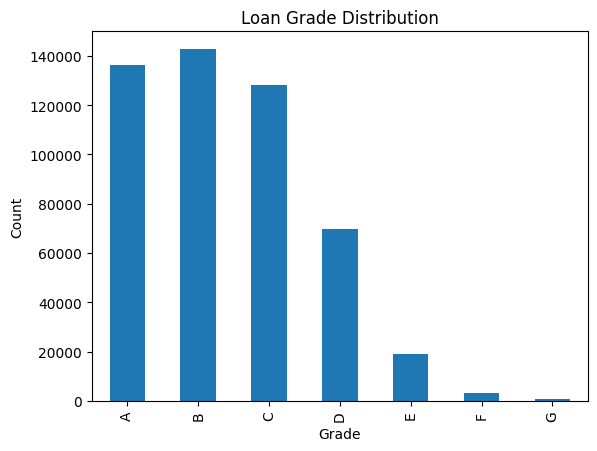

In [56]:
df['grade'].value_counts().sort_index().plot(kind='bar')
plt.title('Loan Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.show()

### Bivariate charts

/tmp/ipykernel_1379/866535275.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6, 4))


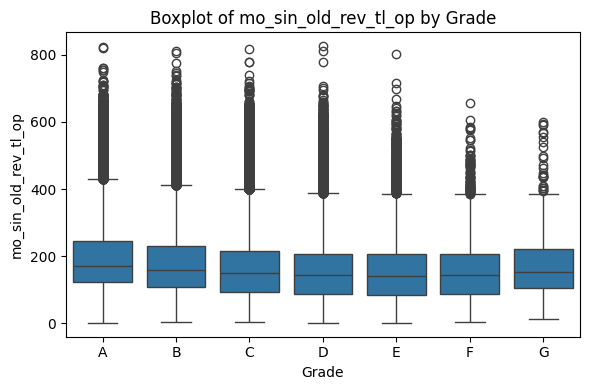

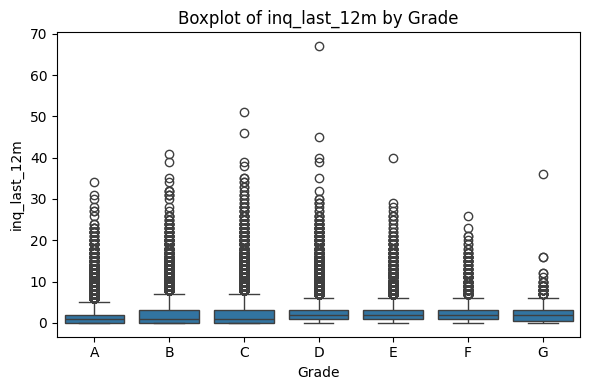

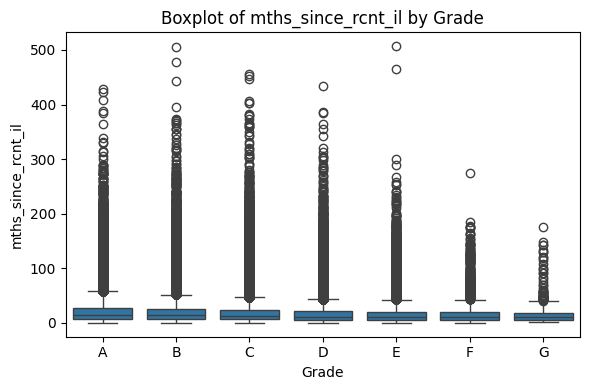

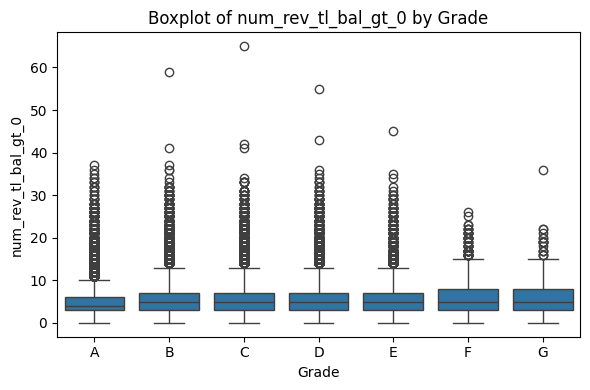

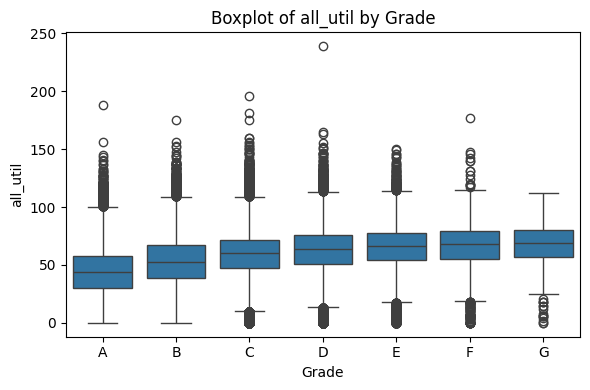

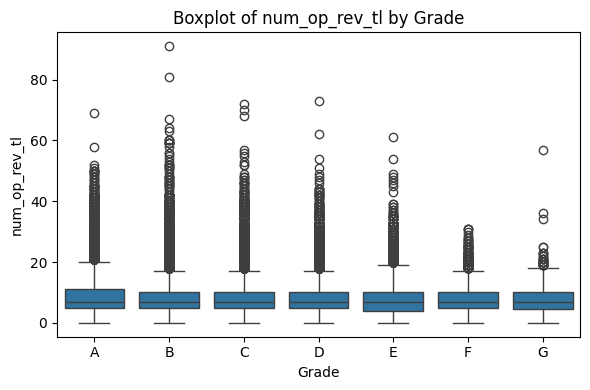

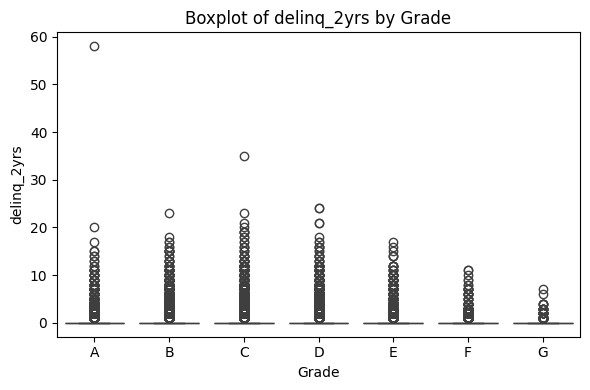

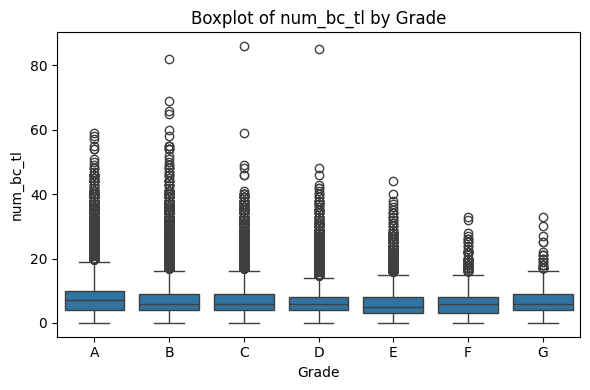

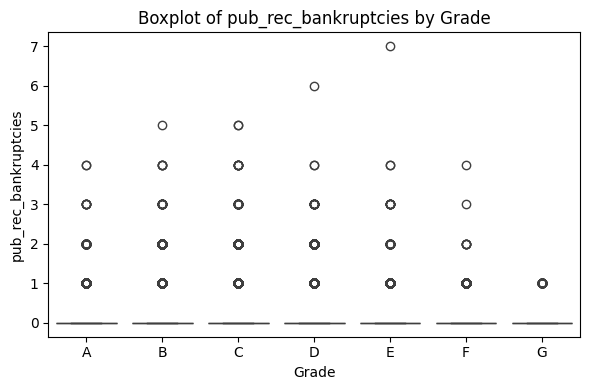

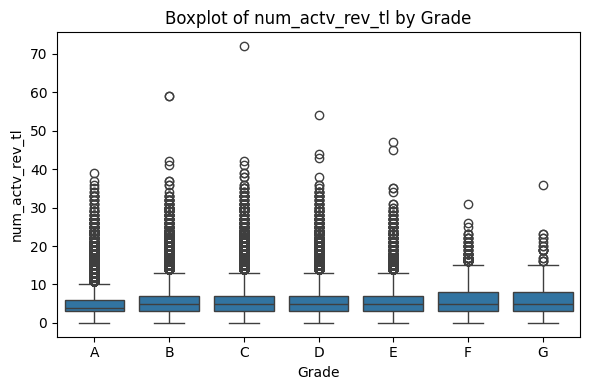

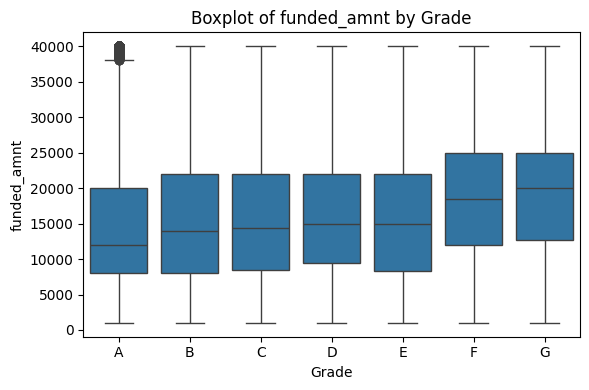

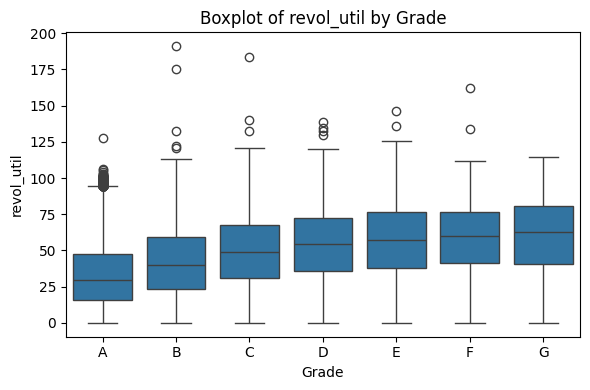

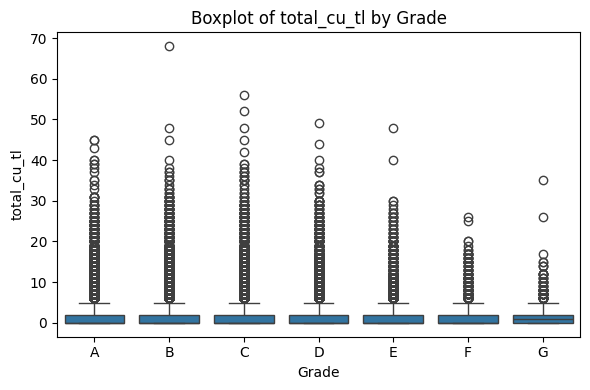

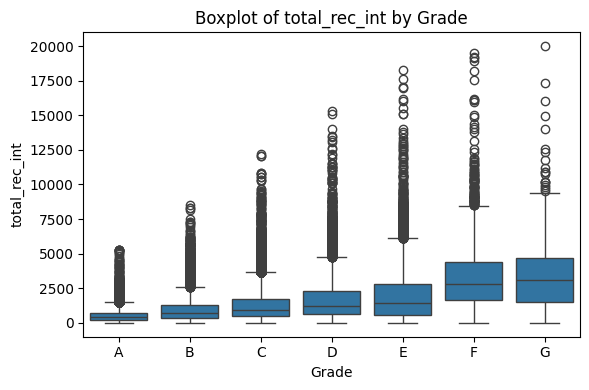

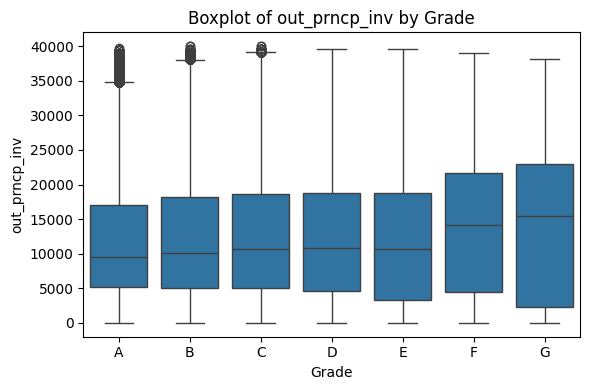

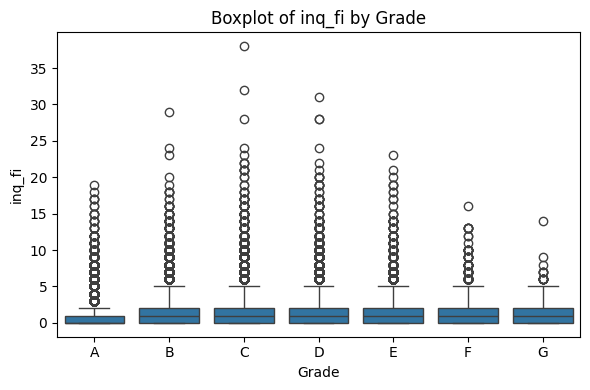

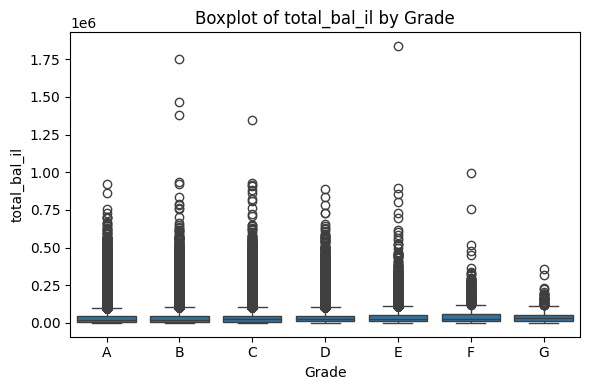

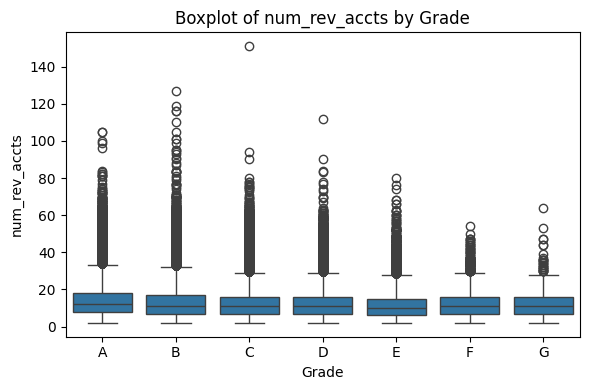

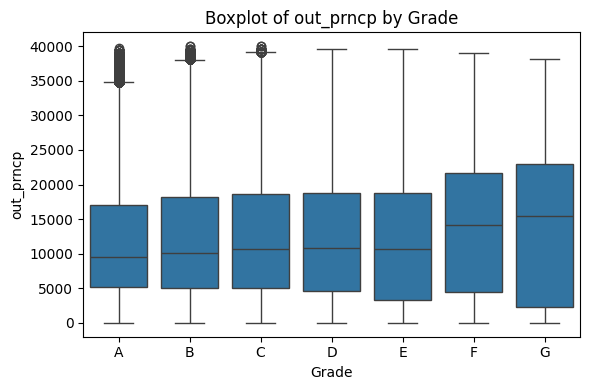

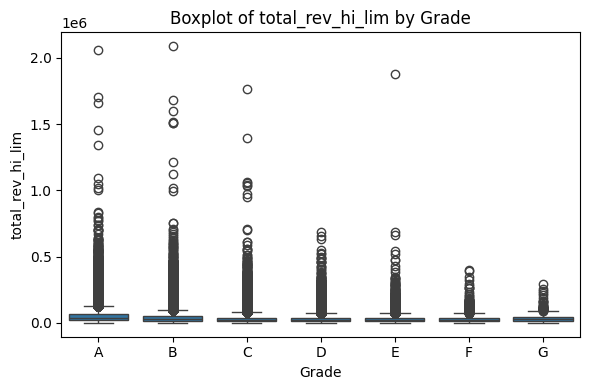

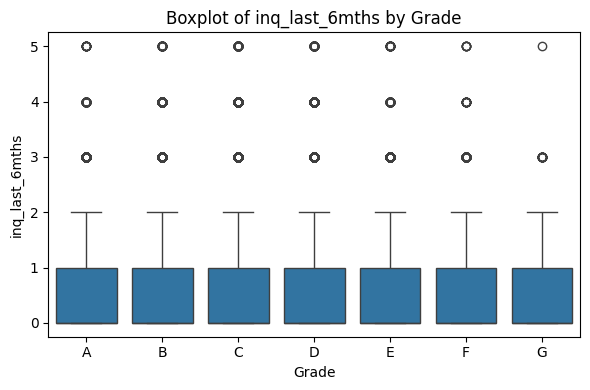

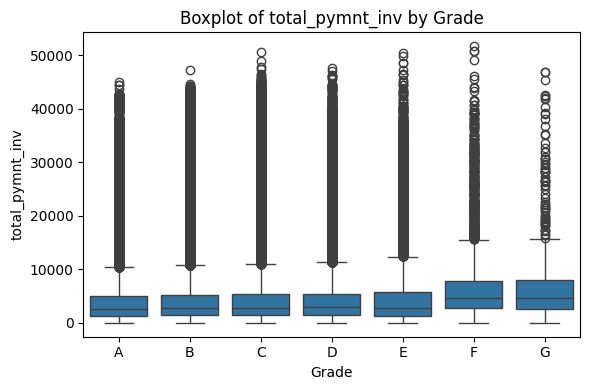

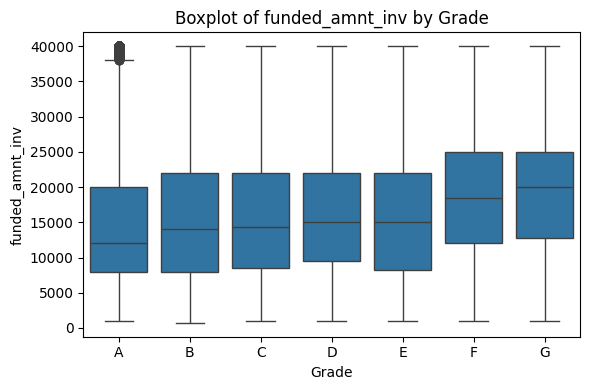

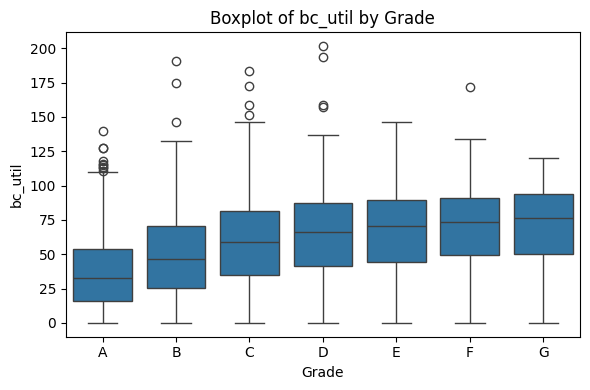

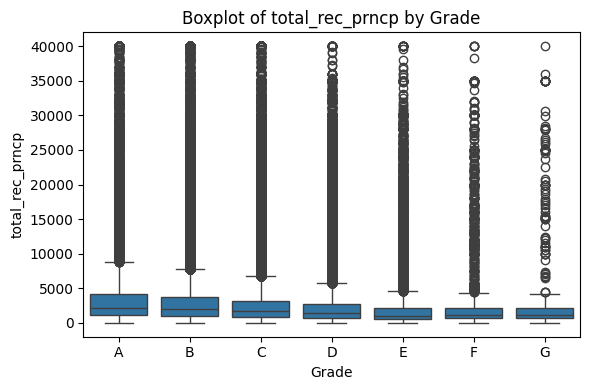

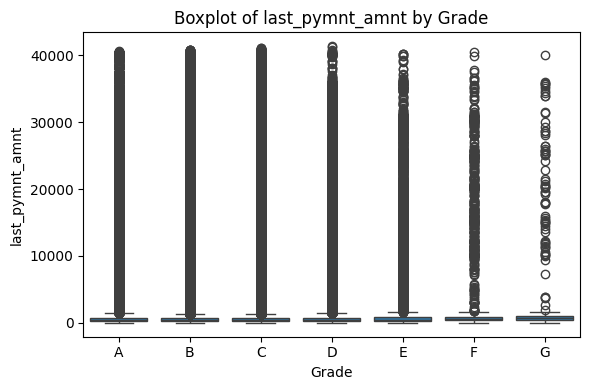

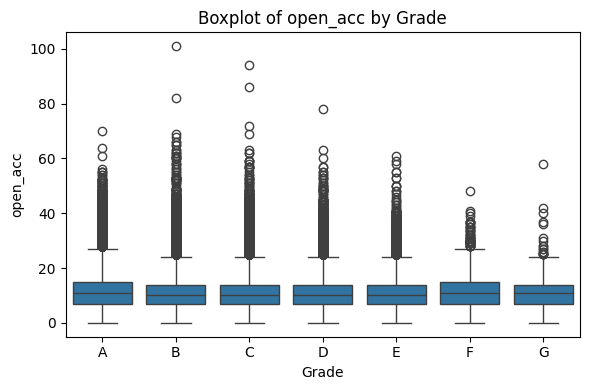

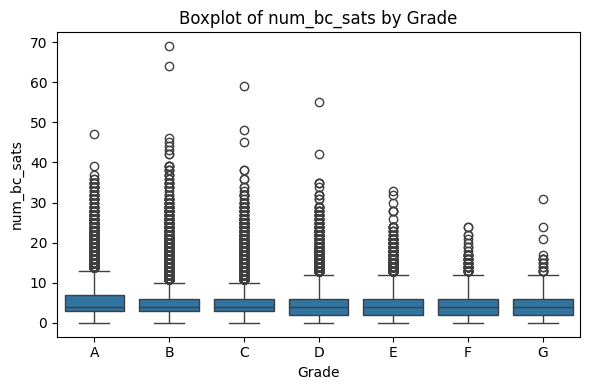

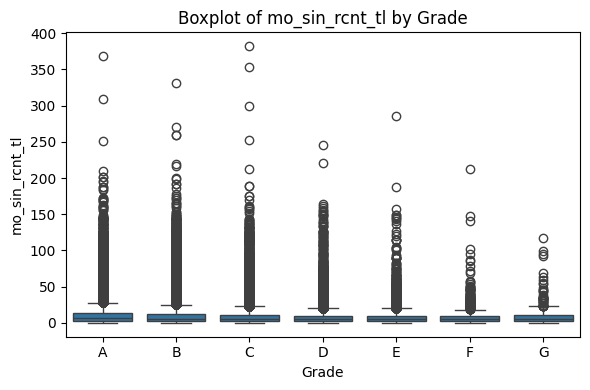

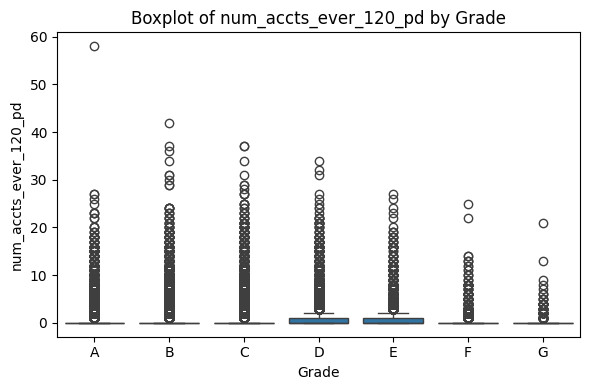

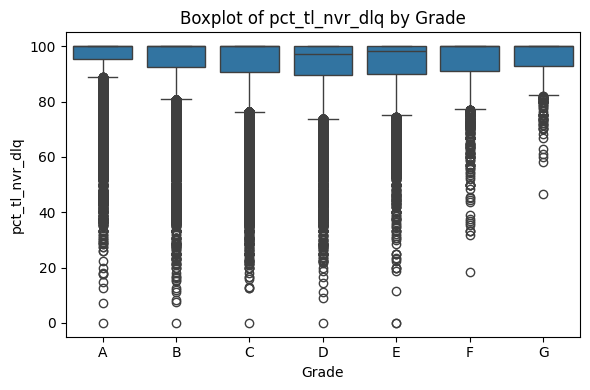

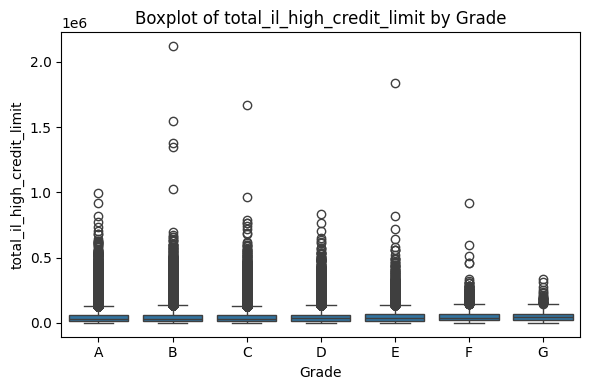

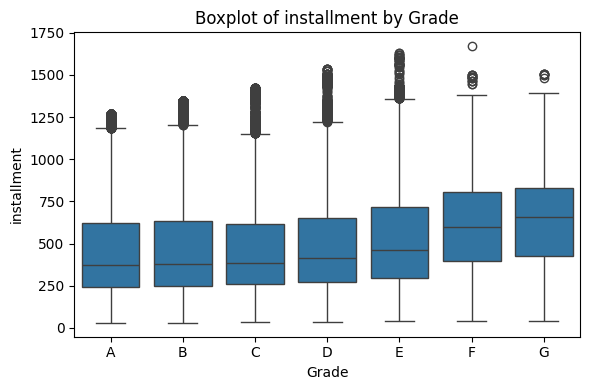

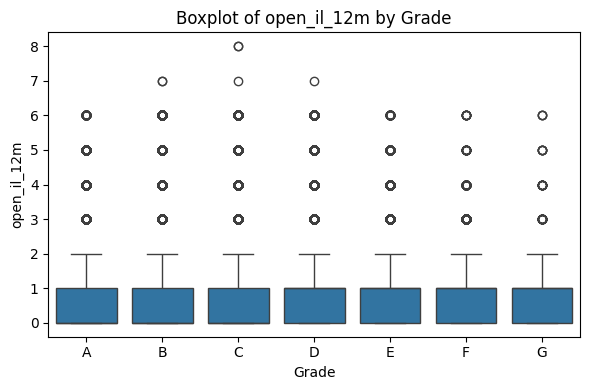

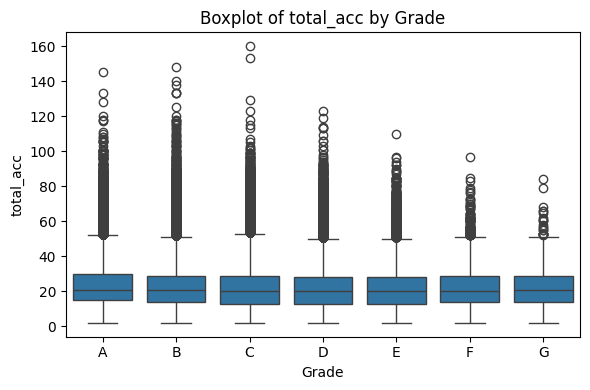

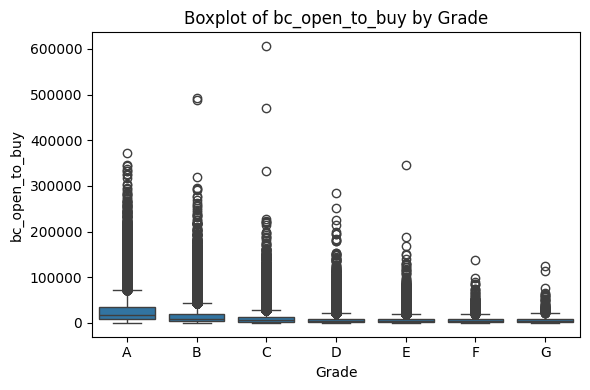

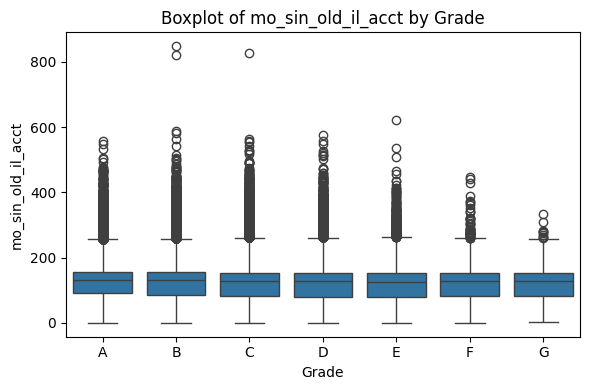

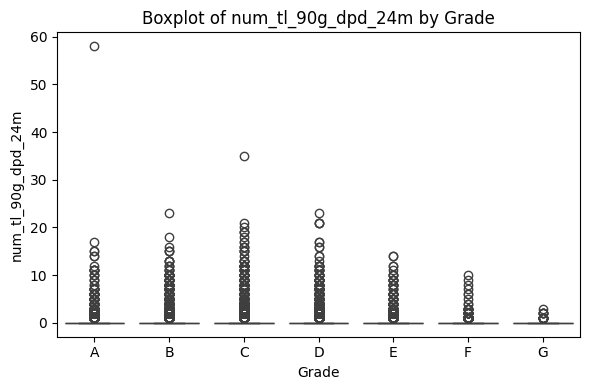

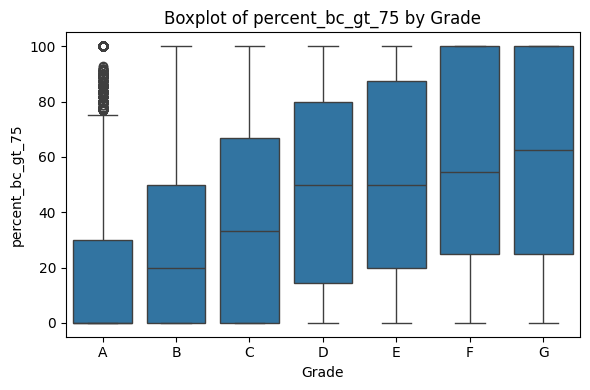

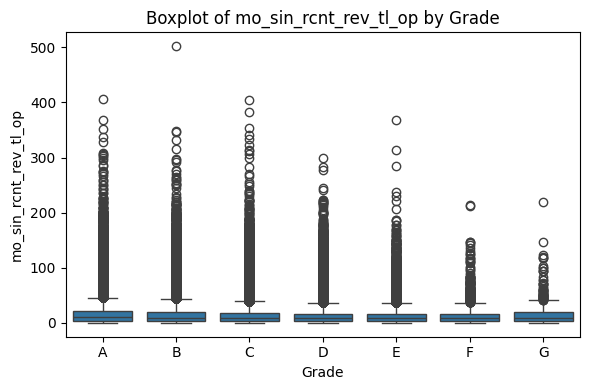

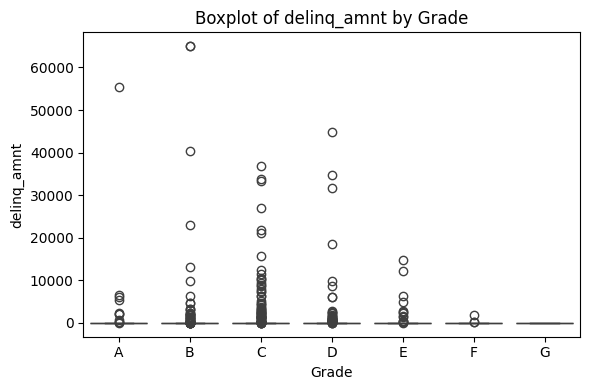

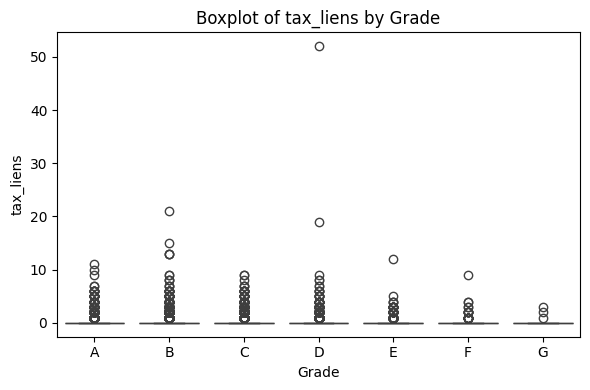

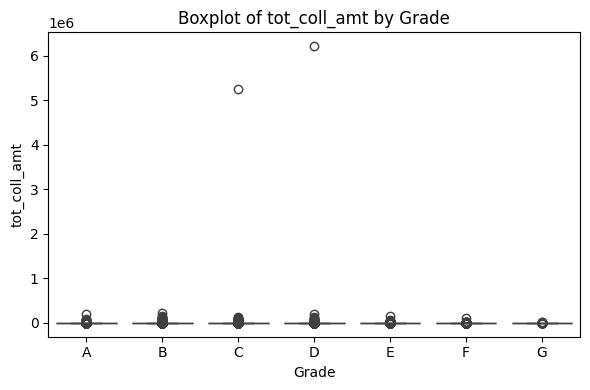

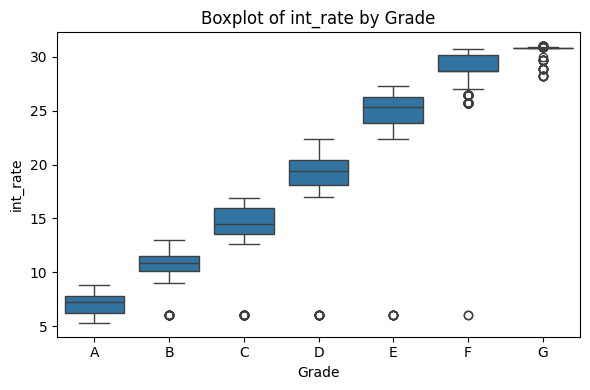

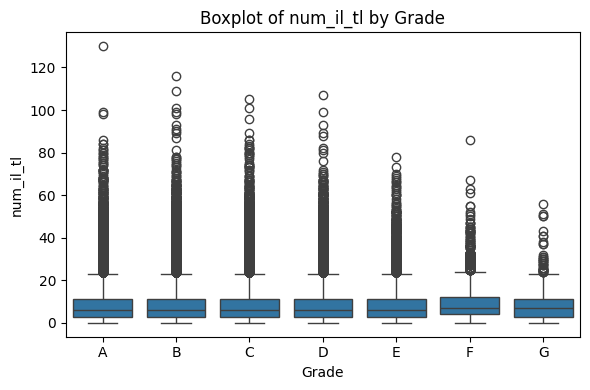

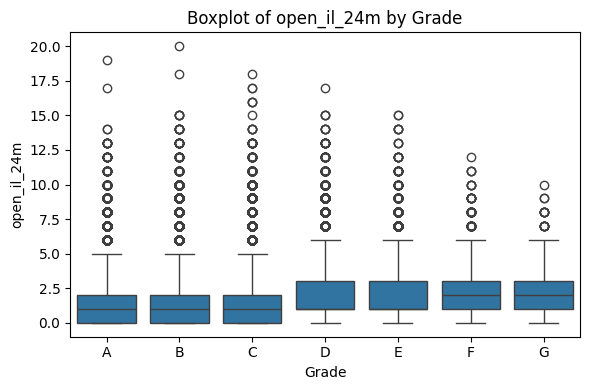

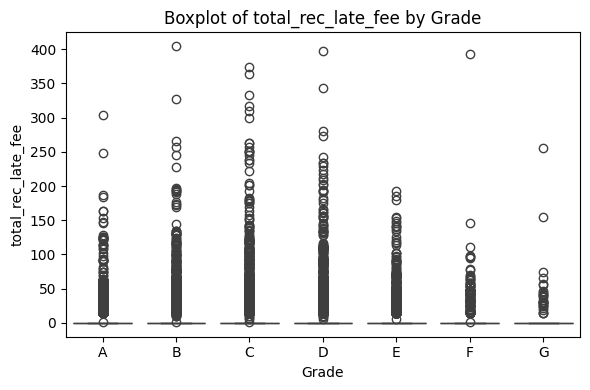

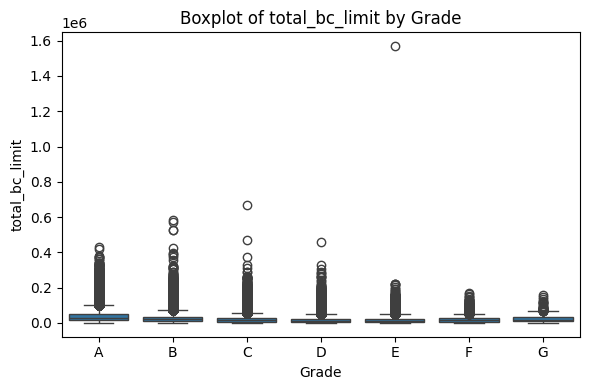

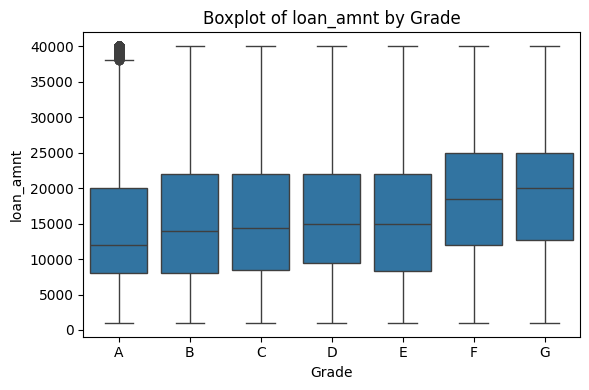

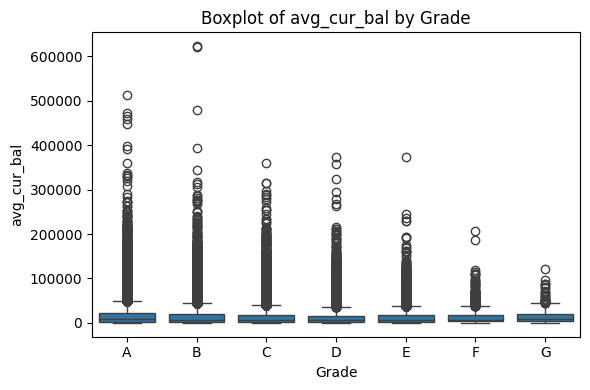

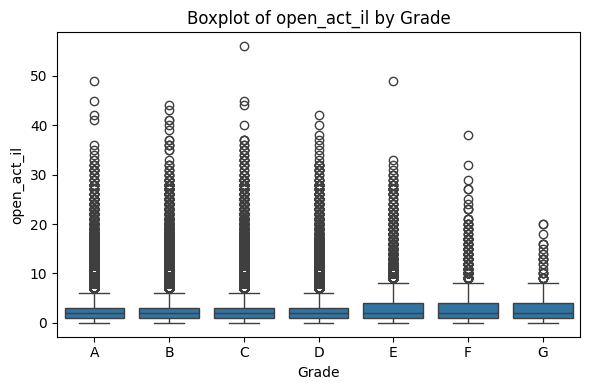

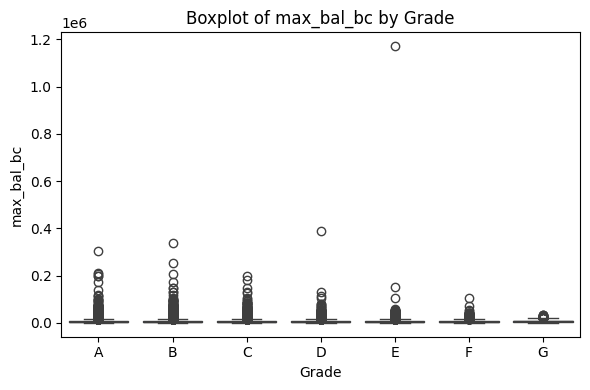

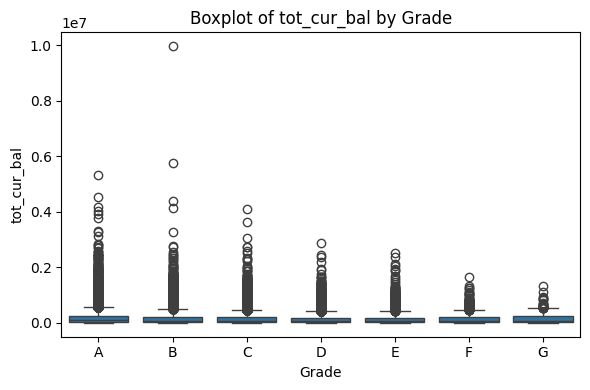

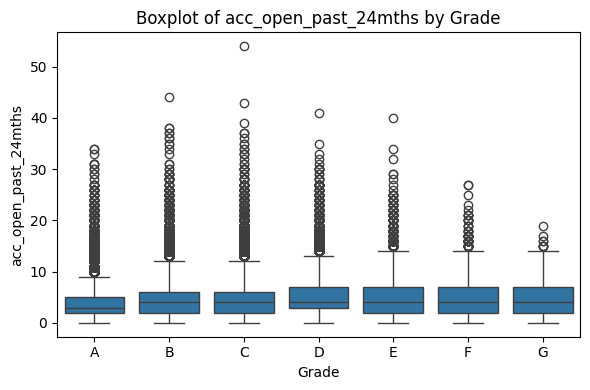

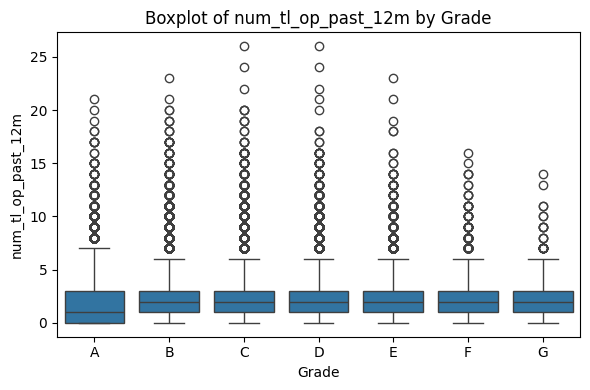

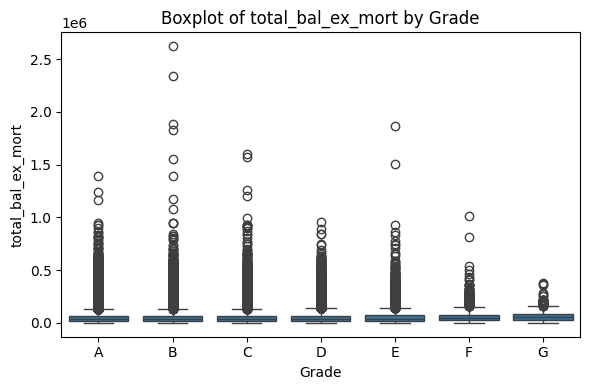

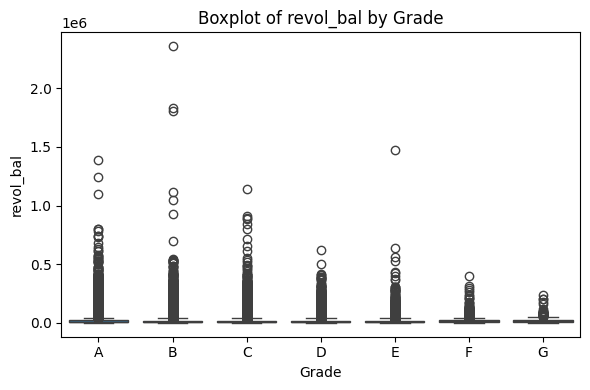

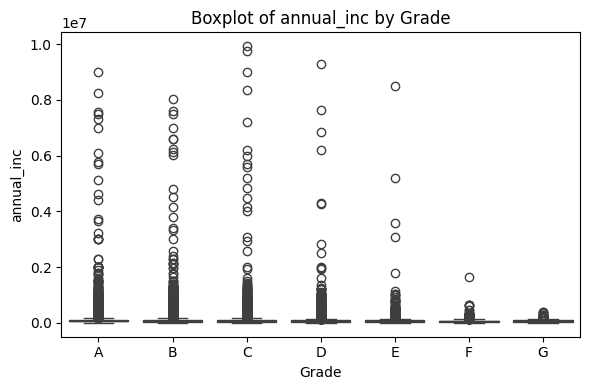

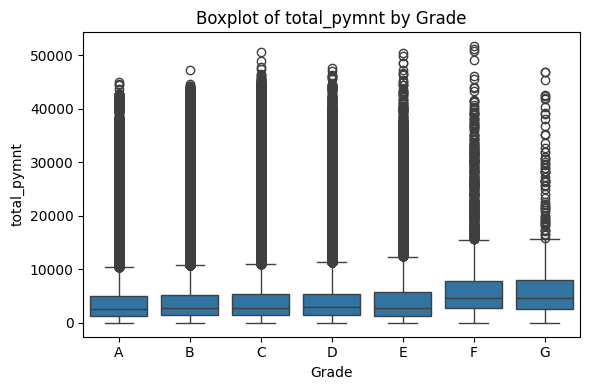

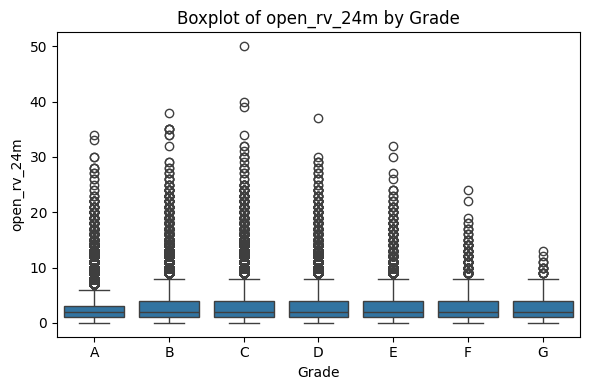

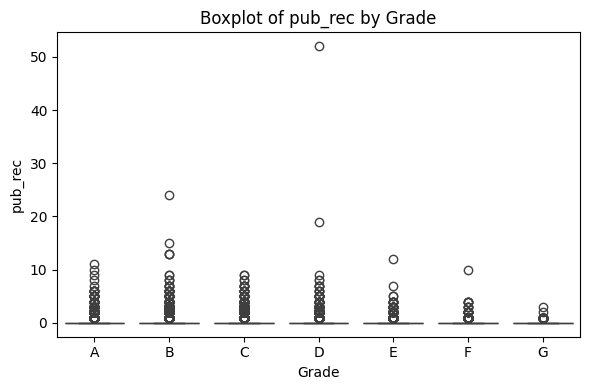

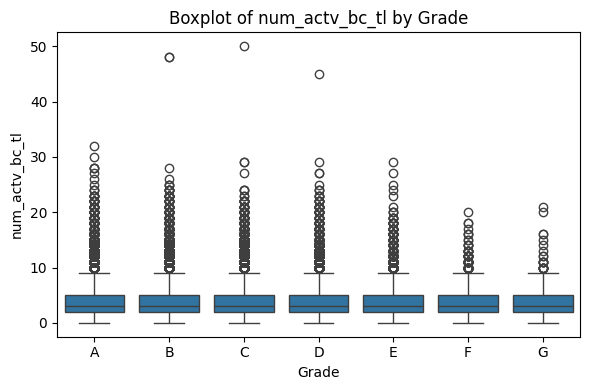

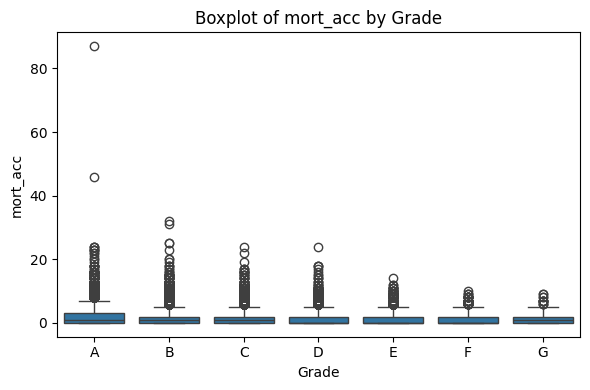

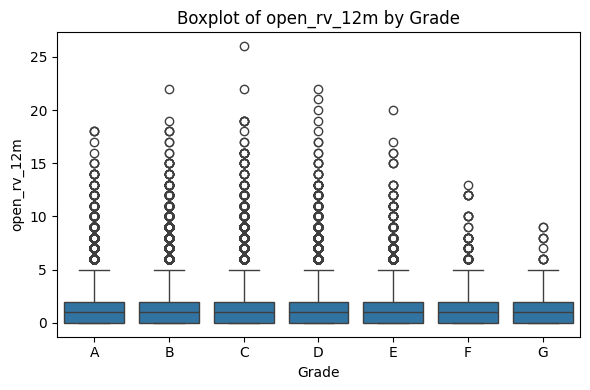

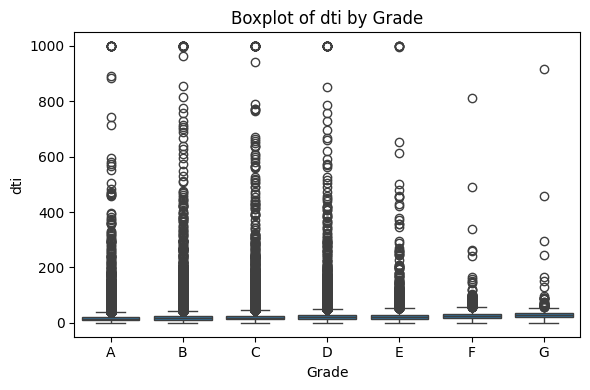

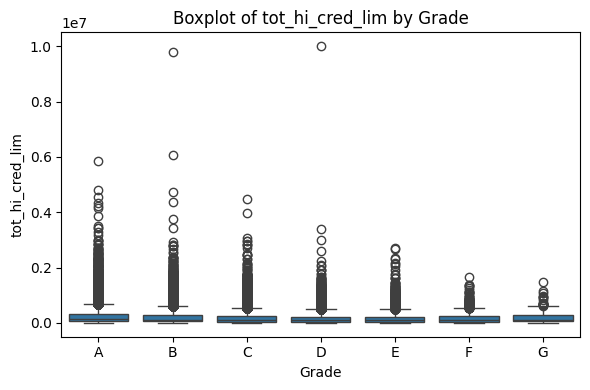

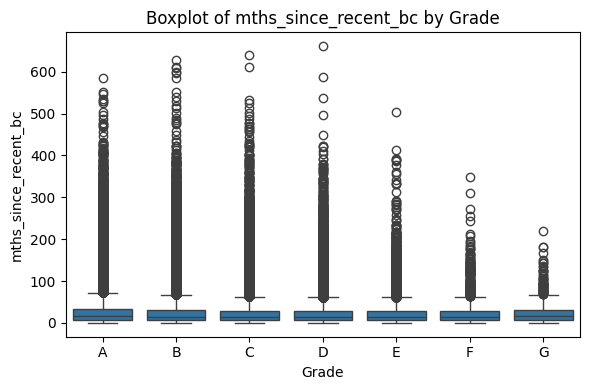

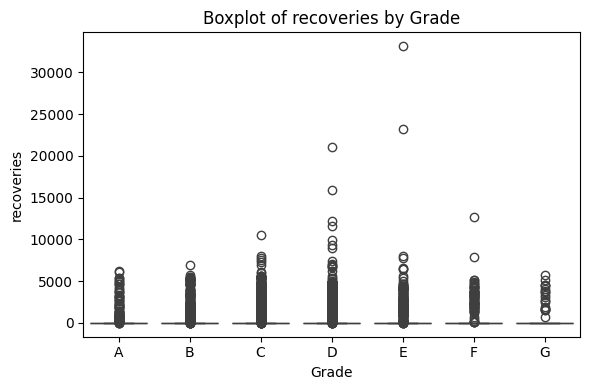

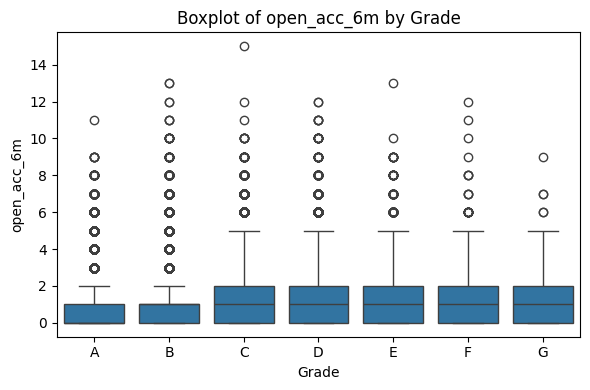

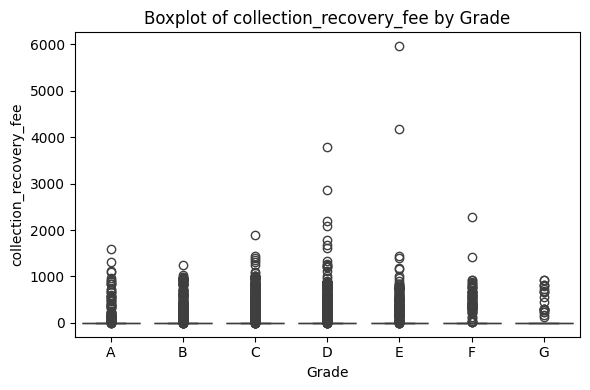

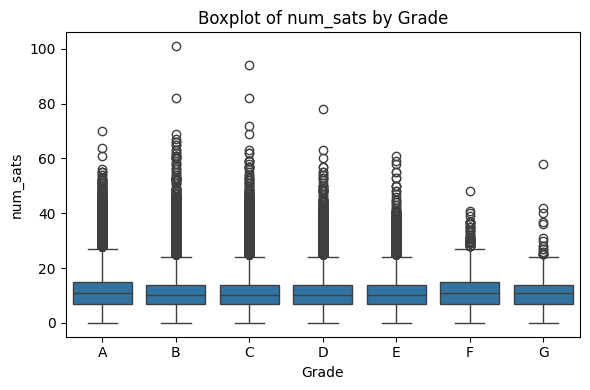

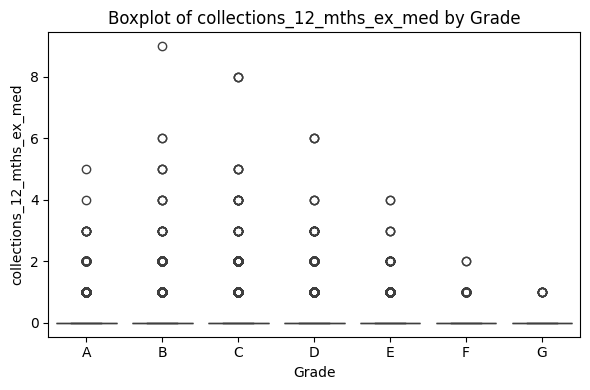

In [57]:
import seaborn as sns

num_features = set(kept) & set(numerical)

for col in num_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x='grade', y=col, order=sorted(df['grade'].unique()))
    plt.title(f'Boxplot of {col} by Grade')
    plt.xlabel('Grade')
    plt.ylabel(col)
    plt.tight_layout()

### Correlation between categorical variables and target

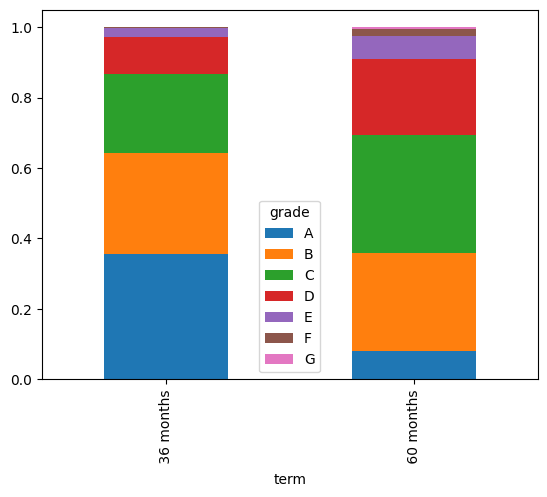

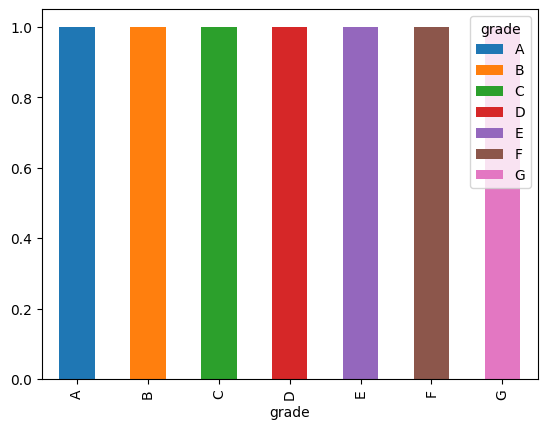

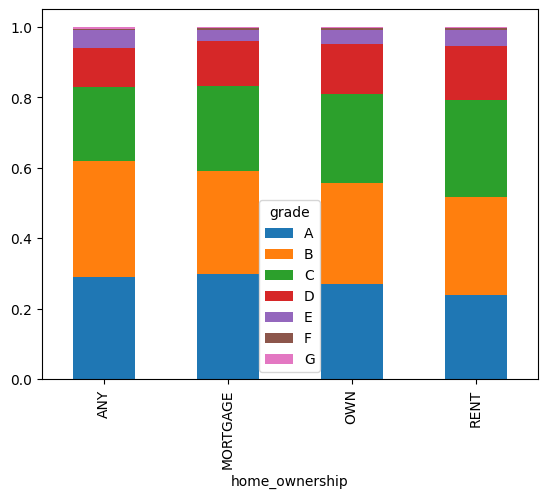

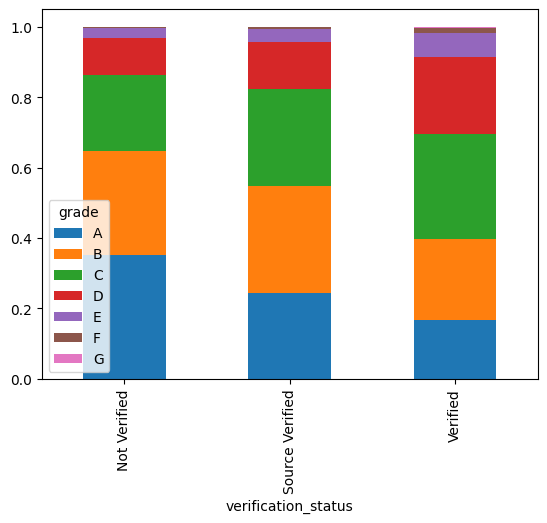

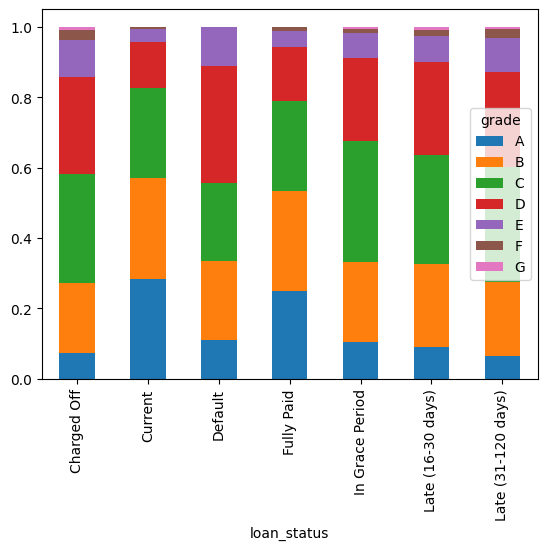

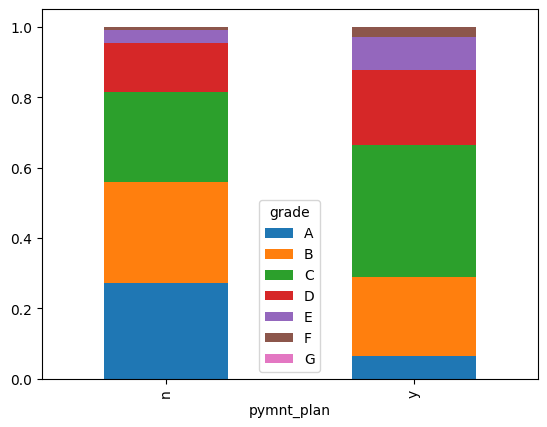

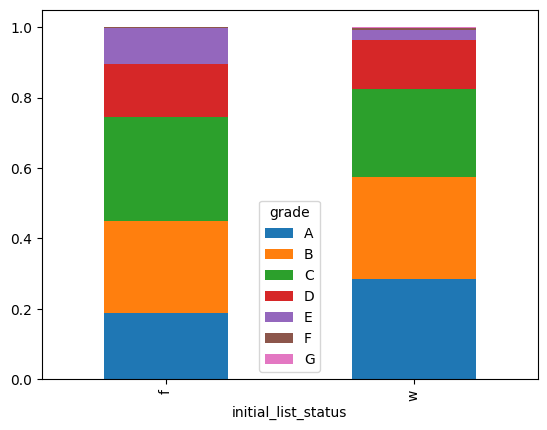

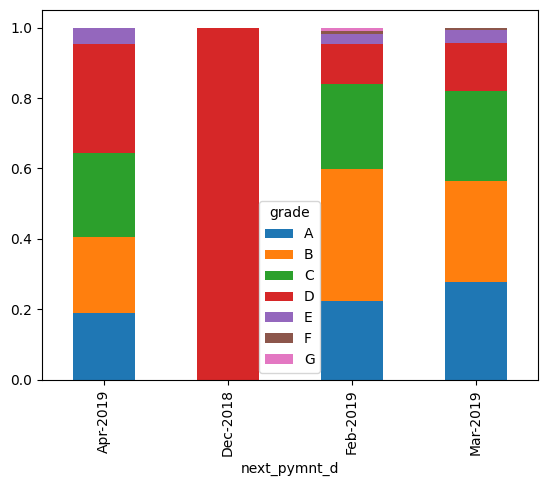

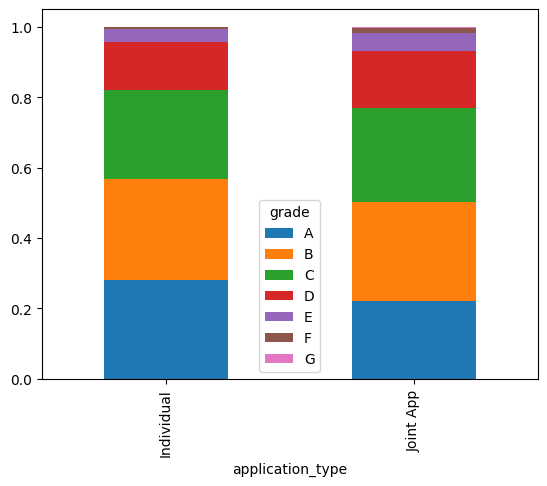

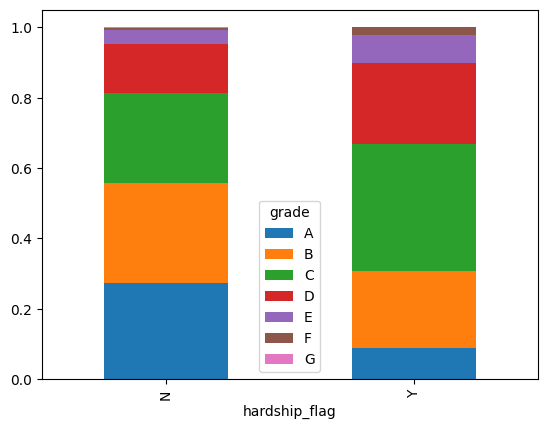

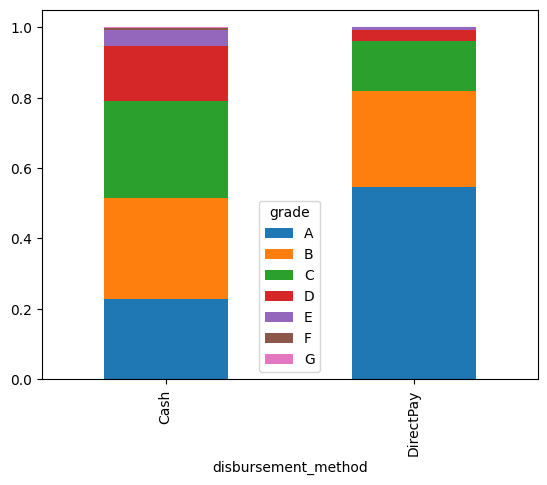

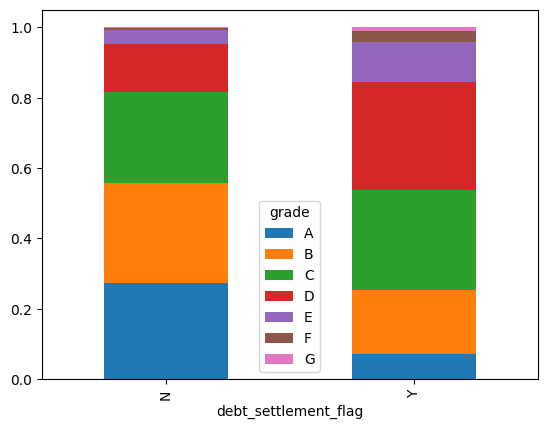

In [58]:

for var in categorical:
    if df[var].nunique() < 10: 
        pd.crosstab(df[var], df['grade'], normalize='index').plot(kind='bar', stacked=True)

### Check correlation

In [59]:
# Encode grade as numeric for correlation
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade_num'] = df['grade'].map(grade_map)

correlations = df.select_dtypes(include='number').corr()['grade_num'].sort_values().dropna()
print(correlations.tail(10))  # most positively correlated
print(correlations.head(10))  # most negatively correlated

inq_last_6mths      0.117199
inq_fi              0.118976
inq_last_12m        0.123496
revol_util          0.302315
percent_bc_gt_75    0.315585
bc_util             0.321109
all_util            0.322943
total_rec_int       0.408558
int_rate            0.970636
grade_num           1.000000
Name: grade_num, dtype: float64
bc_open_to_buy         -0.320631
total_bc_limit         -0.255908
total_rev_hi_lim       -0.213675
pct_tl_nvr_dlq         -0.128402
tot_hi_cred_lim        -0.116598
mo_sin_old_rev_tl_op   -0.116504
mort_acc               -0.109132
num_bc_tl              -0.100678
mo_sin_rcnt_tl         -0.074709
num_bc_sats            -0.073402
Name: grade_num, dtype: float64


In [60]:
del df['grade_num']

<Axes: xlabel='grade'>

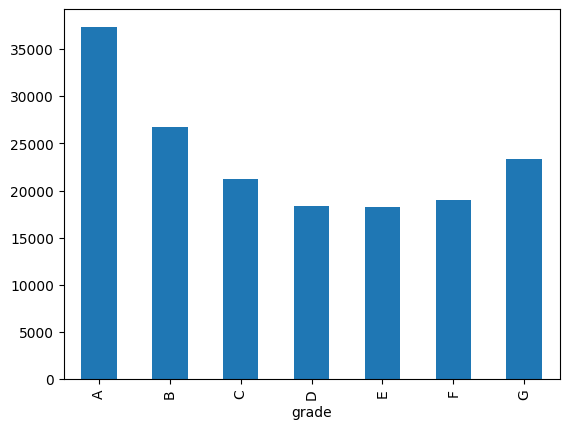

In [61]:
df.groupby('grade')['total_bc_limit'].mean().plot(kind='bar')

Text(0.5, 1.0, 'Feature Correlation Heatmap (|r| > 0.5)')

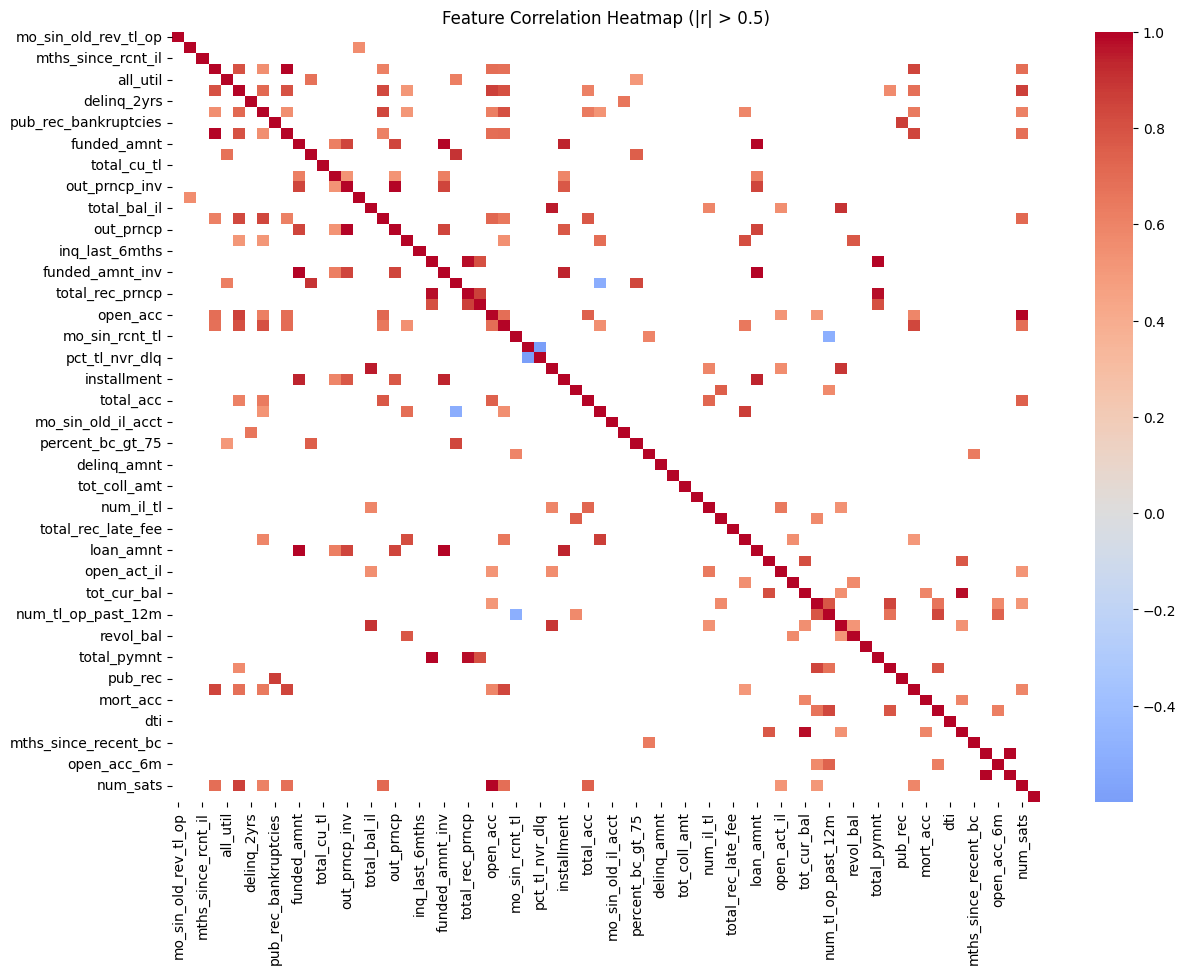

In [62]:
corr = df[list(num_features)].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, 
            mask=corr.abs() < 0.5,  # only show meaningful correlations
            annot=False)
plt.title('Feature Correlation Heatmap (|r| > 0.5)')

### Target variable vs. missing value correlation

In [63]:
for col in df.columns[df.isnull().any()]:
    null_by_grade = df.groupby('grade')[col].apply(lambda x: x.isnull().mean())
    if null_by_grade.std() > 0.01:  # meaningful variation
        print(f"{col}:\n{null_by_grade}\n")

emp_length:
grade
A    0.077662
B    0.084343
C    0.086997
D    0.090274
E    0.094730
F    0.089243
G    0.119424
Name: emp_length, dtype: float64

next_pymnt_d:
grade
A    0.081351
B    0.094886
C    0.102689
D    0.122434
E    0.143682
F    0.194712
G    0.197122
Name: next_pymnt_d, dtype: float64

num_tl_120dpd_2m:
grade
A    0.006826
B    0.024168
C    0.033645
D    0.037216
E    0.047079
F    0.054087
G    0.093525
Name: num_tl_120dpd_2m, dtype: float64



### Recheck missing values

In [64]:
df.isnull().mean().sort_values(ascending = False)

,0
next_pymnt_d,0.099722
emp_length,0.084512
mths_since_rcnt_il,0.037062
mo_sin_old_il_acct,0.037062
num_tl_120dpd_2m,0.024872
bc_util,0.013742
percent_bc_gt_75,0.013328
bc_open_to_buy,0.013312
mths_since_recent_bc,0.012520
dti,0.002266


#### Drop categorical variables with more than 10 levels

This helps save the computation from encoding categorical variables

In [65]:
for var in categorical:
    if df[var].nunique() > 10:
        del df[var]

#### Drop variables with target leakage

Many of these columns describe what happened after the loan was issued, not at origination.

In [66]:
leakage_cols = [
    # Post-origination payment data
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
    'total_rec_int', 'total_rec_late_fee', 'recoveries',
    'collection_recovery_fee', 'last_pymnt_amnt',
    'out_prncp', 'out_prncp_inv', 'disbursement_method',
    
    # Loan status after origination
    'loan_status',
    
    # Payment plan info
    'pymnt_plan', 'last_pymnt_d',
    
    # Next payment date (post-origination)
    'next_pymnt_d',
    
    # Hardship/settlement (post-origination)
    'hardship_flag', 'debt_settlement_flag',
    
    # Already removing these
    'int_rate', 'sub_grade'
]
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

### Data split

In [67]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size = 0.2, stratify=df['grade'])
df_train, df_val = train_test_split(df_full_train, test_size = 0.25, stratify=df_full_train['grade'])

df_train.shape, df_val.shape, df_test.shape

((300000, 72), (100000, 72), (100000, 72))

In [68]:
y_train = df_train['grade']
y_val = df_val['grade']
y_test = df_test['grade']

del df_train['grade']
del df_val['grade']
del df_test['grade']


### Data preprocessing

In [69]:
from sklearn.feature_extraction import DictVectorizer

dv = DictVectorizer(sparse = False)

train_dict = df_train.to_dict(orient = 'records')
val_dict = df_val.to_dict(orient = 'records')
test_dict = df_test.to_dict(orient = 'records')

X_train = dv.fit_transform(train_dict)
X_val = dv.transform(val_dict)
X_test = dv.transform(test_dict)



## Model development

#### Baseline model

In [70]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=10, criterion='log_loss', max_features='sqrt', max_depth=5,
                               random_state=42, n_jobs=-1)


model.fit(X_train, y_train)



RandomForestClassifier(criterion='log_loss', max_depth=5, n_estimators=10,
                       n_jobs=-1, random_state=42)

In [71]:
from sklearn.metrics import log_loss, accuracy_score, f1_score, confusion_matrix, classification_report

y_pred = model.predict_proba(X_val)
y_pred_class = model.predict(X_val)

print('log loss is', log_loss(y_val, y_pred))



log loss is 1.305659339053303


#### Feature importance

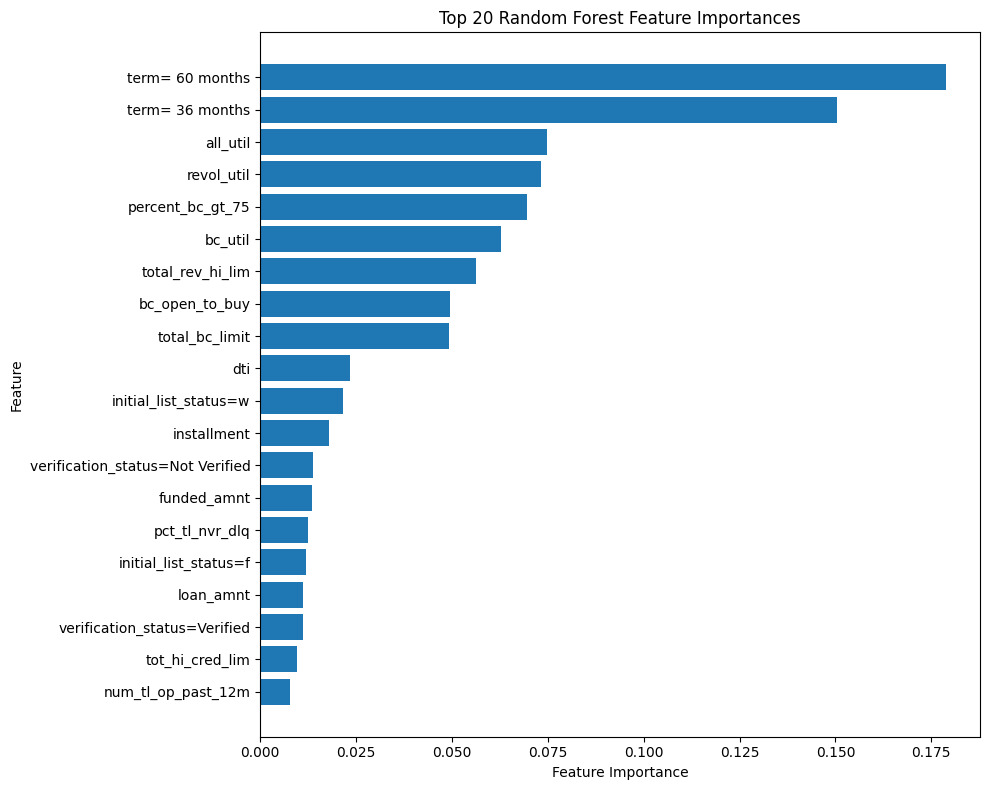

In [72]:
# feature names
feature_names = dv.get_feature_names_out()

# importance dataframe
fi = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# top 20 features
top_n = 20
fi_top = fi.head(top_n).sort_values('importance')

plt.figure(figsize=(10, 8))
plt.barh(fi_top['feature'], fi_top['importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Random Forest Feature Importances')
plt.tight_layout()
plt.show()

#### Hyperparameter tuning


In [73]:

scores = []

for depth in [5, 7, 9, 11, 13]:

    for min_samples in [10, 20, 30, 40]:

        model = RandomForestClassifier(n_estimators=50, 
                                       criterion='log_loss', 
                                       max_features='sqrt', 
                                       max_depth=depth,
                                       min_samples_leaf=min_samples,
                                       random_state=42, 
                                       n_jobs=-1)

        model.fit(X_train, y_train)

        from sklearn.metrics import log_loss, accuracy_score, f1_score, confusion_matrix, classification_report

        y_prob = model.predict_proba(X_val)
        # for multi-class problems
        y_pred = model.classes_[y_prob.argmax(axis=1)]

        accuracy = accuracy_score(y_val, y_pred)

        logloss = log_loss(y_val, y_prob)
        macro_f1 = f1_score(y_val, y_pred, average='macro')
        weighted_f1 = f1_score(y_val, y_pred, average='weighted')


        scores.append([depth, min_samples, accuracy, logloss, macro_f1, weighted_f1])

scores_df = pd.DataFrame(scores, columns = ['max_depth', 'min_samples_leaf', 'accuracy', 'logloss', 'F1 score macro', 'F1 score weighted'])

    

In [74]:
scores_df

,max_depth,min_samples_leaf,accuracy,logloss,F1 score macro,F1 score weighted
0,5,10,0.45529,1.299427,0.215197,0.408300
1,5,20,0.45527,1.299428,0.215188,0.408281
2,5,30,0.45533,1.299426,0.215214,0.408332
3,5,40,0.45539,1.299731,0.215301,0.408485
4,7,10,0.48352,1.248188,0.242941,0.446139
5,7,20,0.48306,1.247836,0.242629,0.445714
6,7,30,0.48355,1.247756,0.242781,0.446297
7,7,40,0.48406,1.245940,0.244081,0.447322
8,9,10,0.50654,1.200532,0.270042,0.477369
9,9,20,0.50541,1.204811,0.266991,0.475349


In [75]:
def visualize_metric(metric = 'F1 score macro'):

    pivot = scores_df.pivot(
        index='max_depth',
        columns='min_samples_leaf',
        values=metric
    )

    plt.figure(figsize=(8, 5))
    plt.imshow(pivot, aspect='auto')
    plt.colorbar(label=metric)
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xlabel('min_samples_leaf')
    plt.ylabel('max_depth')
    plt.title(f'Hyperparameter tuning heatmap: {metric}')
    plt.show()

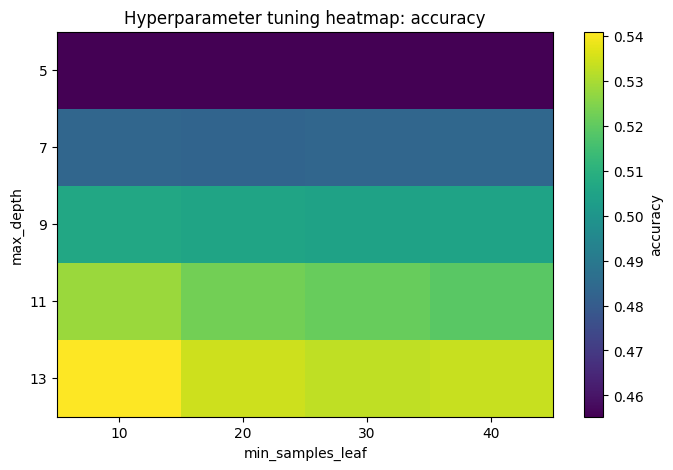

In [76]:
visualize_metric(metric = 'accuracy')

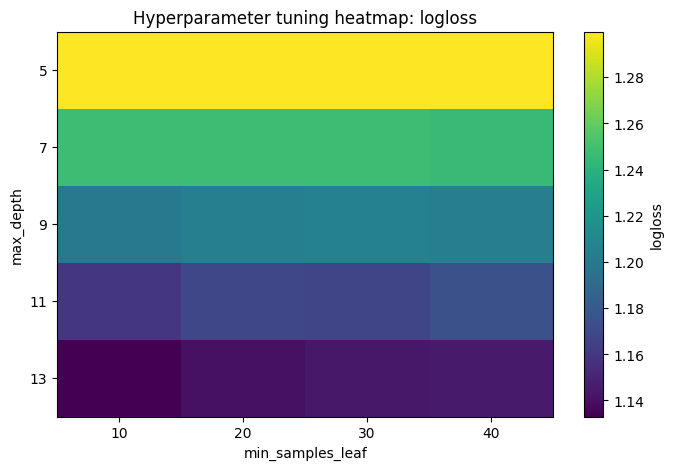

In [77]:
visualize_metric(metric = 'logloss')

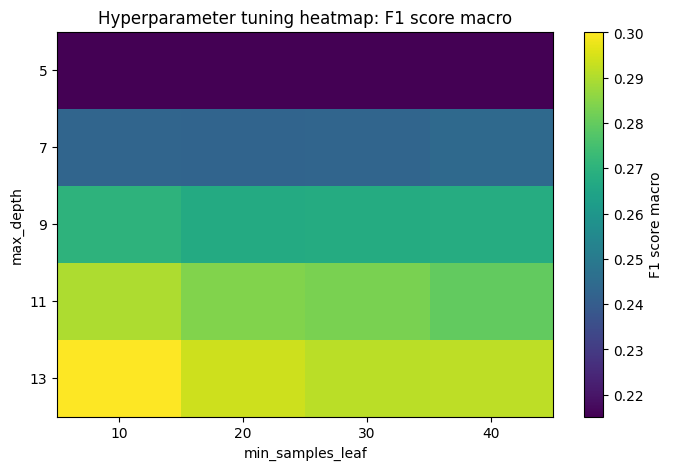

In [78]:
visualize_metric(metric = 'F1 score macro')

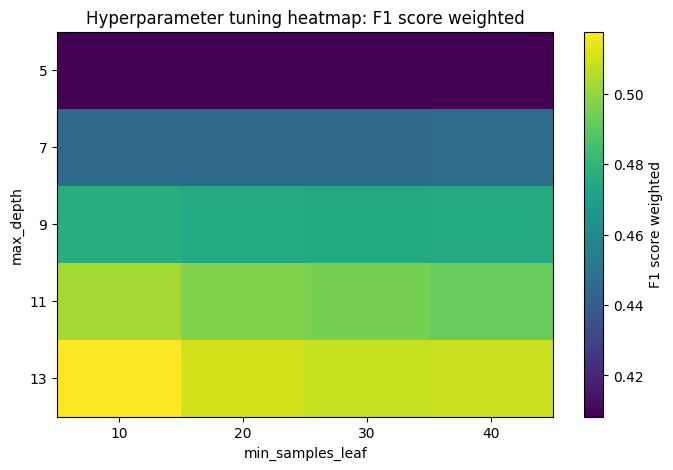

In [79]:
visualize_metric(metric = 'F1 score weighted')

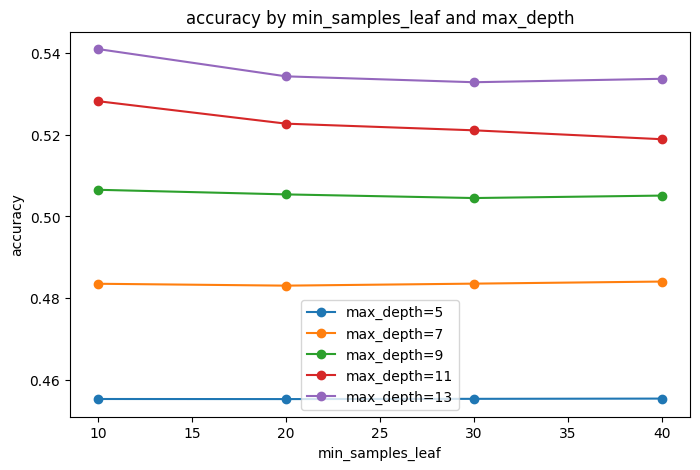

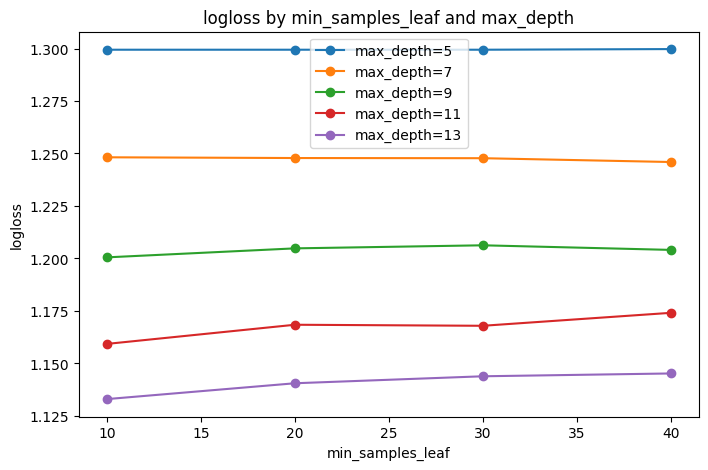

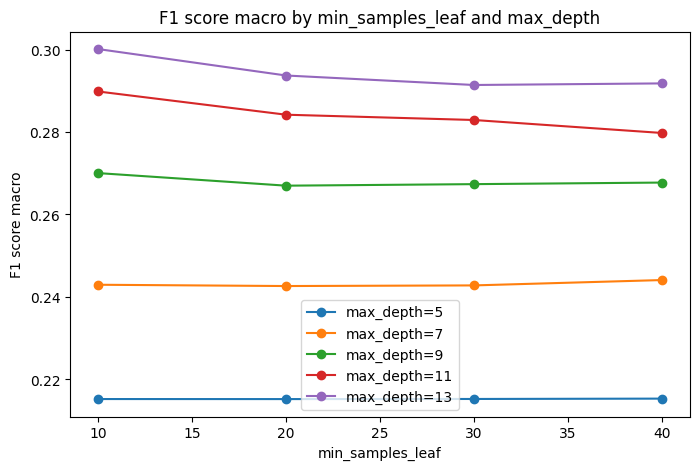

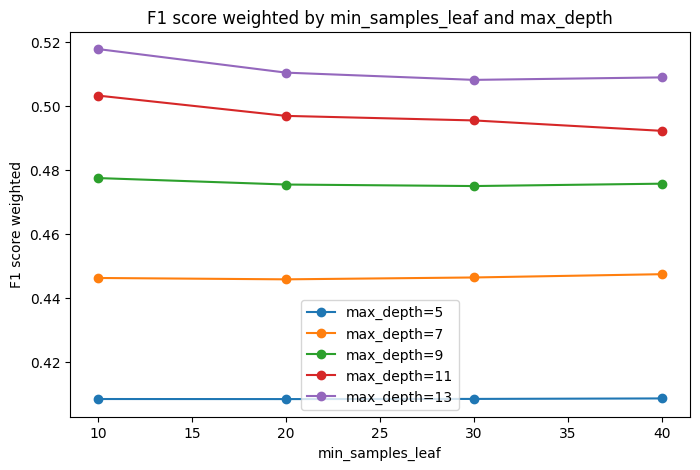

In [80]:

for metric in ['accuracy', 'logloss', 'F1 score macro', 'F1 score weighted']:

    plt.figure(figsize=(8, 5))

    for depth in sorted(scores_df['max_depth'].unique()):
        subset = scores_df[scores_df['max_depth'] == depth].sort_values('min_samples_leaf')
        plt.plot(subset['min_samples_leaf'], subset[metric], marker='o', label=f'max_depth={depth}')

    plt.xlabel('min_samples_leaf')
    plt.ylabel(metric)
    plt.title(f'{metric} by min_samples_leaf and max_depth')
    plt.legend()
    plt.show()

In [81]:
# Conclusion

# The best combination of hyperparameters -

max_depth = 13
min_samples_leaf = 10

#### Finalize random forest model

In [82]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=50, 
                                criterion='log_loss', 
                                max_features='sqrt', 
                                max_depth=max_depth,
                                min_samples_leaf=min_samples_leaf,
                                random_state=42, 
                                n_jobs=-1)

rf_model.fit(X_train, y_train)

RandomForestClassifier(criterion='log_loss', max_depth=13, min_samples_leaf=10,
                       n_estimators=50, n_jobs=-1, random_state=42)

In [83]:
import joblib

# Save
joblib.dump(rf_model, 'random_forest_model.pkl')

# Load back
rf_model = joblib.load('random_forest_model.pkl')

In [84]:
def model_perf(X = X_val, y = y_val):

    from sklearn.metrics import log_loss, accuracy_score, f1_score, confusion_matrix, classification_report

    y_prob = rf_model.predict_proba(X)
    # for multi-class problems
    y_pred = rf_model.classes_[y_prob.argmax(axis=1)]

    accuracy = accuracy_score(y, y_pred)

    logloss = log_loss(y, y_prob)
    macro_f1 = f1_score(y, y_pred, average='macro')
    weighted_f1 = f1_score(y, y_pred, average='weighted')

    print(classification_report(y, y_pred))

In [85]:
model_perf(X = X_val, y = y_val)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           A       0.67      0.74      0.70     27221
           B       0.50      0.53      0.52     28550
           C       0.46      0.61      0.52     25656
           D       0.56      0.21      0.30     13924
           E       0.73      0.03      0.06      3845
           F       0.00      0.00      0.00       665
           G       0.00      0.00      0.00       139

    accuracy                           0.54    100000
   macro avg       0.42      0.30      0.30    100000
weighted avg       0.55      0.54      0.52    100000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [86]:
model_perf(X = X_test, y = y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           A       0.67      0.75      0.71     27220
           B       0.49      0.53      0.51     28550
           C       0.46      0.60      0.52     25656
           D       0.57      0.20      0.30     13924
           E       0.68      0.02      0.05      3845
           F       0.00      0.00      0.00       666
           G       0.00      0.00      0.00       139

    accuracy                           0.54    100000
   macro avg       0.41      0.30      0.30    100000
weighted avg       0.55      0.54      0.52    100000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Feature importance

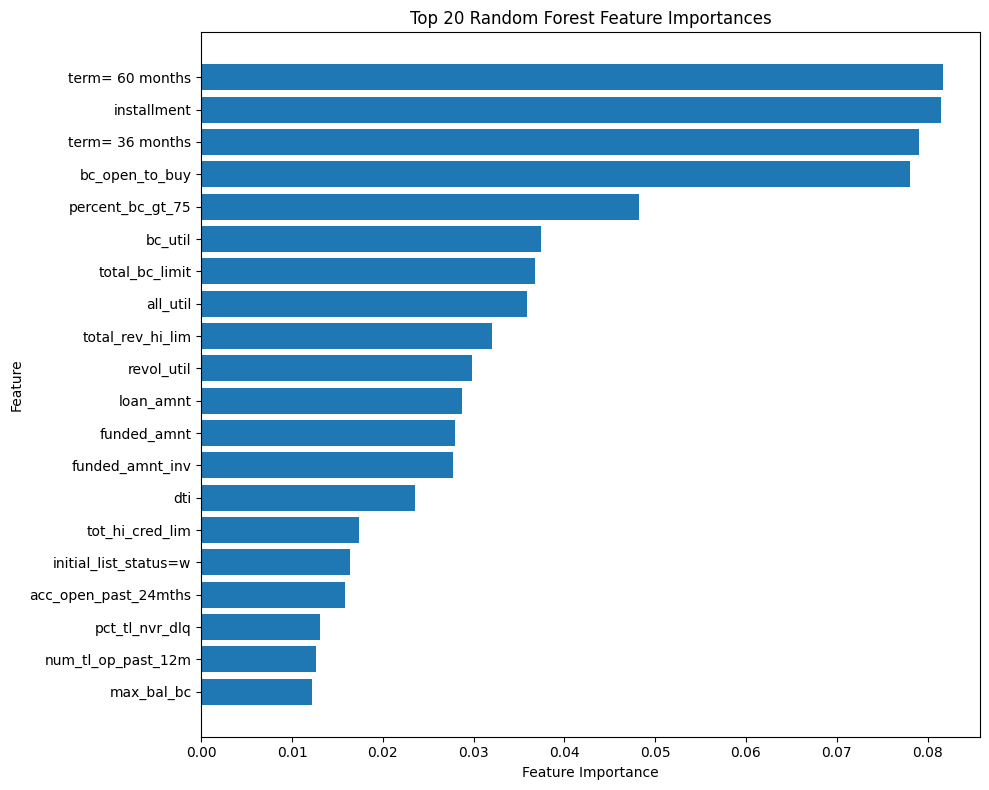

In [87]:
# feature names
feature_names = dv.get_feature_names_out()

# importance dataframe
fi = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# top 20 features
top_n = 20
fi_top = fi.head(top_n).sort_values('importance')

plt.figure(figsize=(10, 8))
plt.barh(fi_top['feature'], fi_top['importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Random Forest Feature Importances')
plt.tight_layout()
plt.show()

#### XGBoost

In [88]:
import xgboost as xgb

Prepare Data
XGBoost needs integer-encoded labels just like PyTorch:

Reuse your existing LabelEncoder from PyTorch section
y_train_enc, y_val_enc, y_test_enc already encoded as 0-6

In [89]:
# Encode target to integers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # 'A'->0, 'B'->1, etc.
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

In [90]:
model_xgb = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=7,
    device='cuda',              # GPU
    tree_method='hist',         # required for GPU
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    early_stopping_rounds=20,   # stops if val loss doesn't improve
    random_state=42
)

model_xgb.fit(
    X_train, y_train_enc,
    eval_set=[(X_val, y_val_enc)],
    verbose=50                  # print every 50 rounds
)

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:06:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-mlogloss:1.45706
[50]	validation_0-mlogloss:0.87378
[100]	validation_0-mlogloss:0.61807
[150]	validation_0-mlogloss:0.47211
[200]	validation_0-mlogloss:0.37384
[250]	validation_0-mlogloss:0.31214
[300]	validation_0-mlogloss:0.27355
[350]	validation_0-mlogloss:0.24647
[400]	validation_0-mlogloss:0.22643
[450]	validation_0-mlogloss:0.21304
[499]	validation_0-mlogloss:0.20280


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cuda', early_stopping_rounds=20,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None, num_class=7, ...)

In [91]:
# evaluate 
def model_perf(X = X_val, y = y_val_enc):
    y_pred_xgb = model_xgb.predict(X)

    # Decode back to grade labels
    y_pred_labels = le.inverse_transform(y_pred_xgb)
    y_labels = le.inverse_transform(y)

    print(classification_report(y_labels, y_pred_labels, target_names=list('ABCDEFG')))
    print(f"Weighted F1: {f1_score(y_labels, y_pred_labels, average='weighted'):.4f}")
    print(f"Macro F1:    {f1_score(y_labels, y_pred_labels, average='macro'):.4f}")

In [92]:
model_perf(X = X_train, y = y_train_enc)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [16:06:34] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


              precision    recall  f1-score   support

           A       0.99      0.98      0.98     81661
           B       0.94      0.95      0.94     85650
           C       0.94      0.94      0.94     76969
           D       0.98      0.97      0.97     41773
           E       0.98      0.99      0.98     11533
           F       1.00      1.00      1.00      1997
           G       1.00      1.00      1.00       417

    accuracy                           0.96    300000
   macro avg       0.97      0.97      0.97    300000
weighted avg       0.96      0.96      0.96    300000

Weighted F1: 0.9599
Macro F1:    0.9748


In [93]:
model_perf(X = X_val, y = y_val_enc)

              precision    recall  f1-score   support

           A       0.98      0.97      0.98     27221
           B       0.91      0.93      0.92     28550
           C       0.91      0.91      0.91     25656
           D       0.95      0.94      0.94     13924
           E       0.92      0.93      0.92      3845
           F       0.85      0.81      0.83       665
           G       0.58      0.20      0.30       139

    accuracy                           0.94    100000
   macro avg       0.87      0.81      0.83    100000
weighted avg       0.94      0.94      0.94    100000

Weighted F1: 0.9363
Macro F1:    0.8295


In [94]:
model_perf(X = X_test, y = y_test_enc)

              precision    recall  f1-score   support

           A       0.98      0.97      0.98     27220
           B       0.91      0.93      0.92     28550
           C       0.92      0.91      0.91     25656
           D       0.95      0.94      0.94     13924
           E       0.91      0.94      0.92      3845
           F       0.84      0.79      0.81       666
           G       0.67      0.16      0.26       139

    accuracy                           0.94    100000
   macro avg       0.88      0.81      0.82    100000
weighted avg       0.94      0.94      0.94    100000

Weighted F1: 0.9358
Macro F1:    0.8212


                             feature  importance
64                   term= 36 months    0.090429
65                   term= 60 months    0.070153
21             initial_list_status=w    0.058955
26                         loan_amnt    0.058126
15                   funded_amnt_inv    0.056065
14                       funded_amnt    0.053742
25                       installment    0.047341
7                     bc_open_to_buy    0.045203
57                  percent_bc_gt_75    0.041608
20             initial_list_status=f    0.037305
78      verification_status=Verified    0.029932
11                       delinq_2yrs    0.026110
1               acc_open_past_24mths    0.022146
48                num_tl_op_past_12m    0.021613
24                    inq_last_6mths    0.020151
76  verification_status=Not Verified    0.020123
72                    total_bc_limit    0.014821
2                           all_util    0.014758
32                          mort_acc    0.014276
38                  

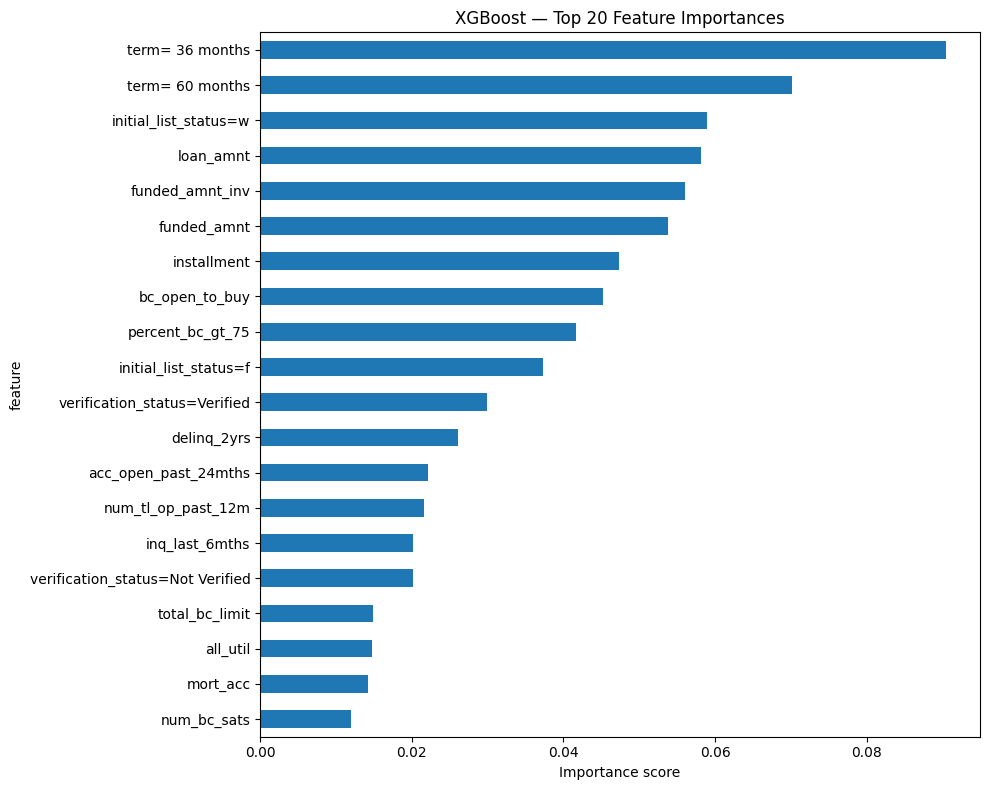

In [95]:

# ── Get feature importance ────────────────────────────────────────────────────
importance = model_xgb.feature_importances_
feature_names = dv.feature_names_

# ── Create a sorted dataframe ─────────────────────────────────────────────────
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

print(feat_imp_df.head(20))

# ── Plot top 20 ───────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
feat_imp_df.head(20).plot(
    kind='barh',
    x='feature',
    y='importance',
    legend=False,
    ax=plt.gca()
)
plt.gca().invert_yaxis()
plt.title('XGBoost — Top 20 Feature Importances')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

#### Neural Networks - MLP

1. Prepare the Data for PyTorch

In [135]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")  # should print: Using device: cuda

Using device: cuda


In [136]:
import numpy as np
import pandas as pd
import kagglehub
import os
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import classification_report, f1_score

def load_data(nrows = 75000):
    # Download latest version
    path = kagglehub.dataset_download("adarshsng/lending-club-loan-data-csv")
    df = pd.read_csv(os.path.join(path, 'loan.csv'), nrows = nrows)
    drop_missing_columns = list(df.columns[df.isnull().sum() > nrows * 0.5])
    df.drop(columns = drop_missing_columns, inplace=True)

    numerical = list(df.dtypes[df.dtypes != 'object'].index)
    categorical = list(df.dtypes[df.dtypes == 'object'].index)

    selector = VarianceThreshold(threshold=0.01)  

    numeric_cols = df.select_dtypes(include='number').columns

    selector.fit(df[numeric_cols])

    kept = numeric_cols[selector.get_support()]
    dropped = numeric_cols[~selector.get_support()]

    for var in categorical:
        if df[var].nunique() > 10:
            del df[var]

    leakage_cols = [
        # Post-origination payment data
        'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
        'total_rec_int', 'total_rec_late_fee', 'recoveries',
        'collection_recovery_fee', 'last_pymnt_amnt',
        'out_prncp', 'out_prncp_inv', 'disbursement_method',
        
        # Loan status after origination
        'loan_status',
        
        # Payment plan info
        'pymnt_plan',
        
        # Next payment date (post-origination)
        'last_pymnt_d', 'next_pymnt_d',
        
        # Hardship/settlement (post-origination)
        'hardship_flag', 'debt_settlement_flag',
        
        # Already removing these
        'int_rate', 'sub_grade'
    ]
    df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

    df_full_train, df_test = train_test_split(df, test_size = 0.2, stratify=df['grade'])
    df_train, df_val = train_test_split(df_full_train, test_size = 0.25, stratify=df_full_train['grade'])

    y_train = df_train['grade']
    y_val = df_val['grade']
    y_test = df_test['grade']

    del df_train['grade']
    del df_val['grade']
    del df_test['grade']



    dv = DictVectorizer(sparse = False)

    train_dict = df_train.to_dict(orient = 'records')
    val_dict = df_val.to_dict(orient = 'records')
    test_dict = df_test.to_dict(orient = 'records')

    X_train = dv.fit_transform(train_dict)
    X_val = dv.transform(val_dict)
    X_test = dv.transform(test_dict)

    return X_train, X_val, X_test, y_train, y_val, y_test, dv

#### Data preprocessing

In [137]:
X_train, X_val, X_test, y_train, y_val, y_test, dv = load_data(nrows = 500000)

Using Colab cache for faster access to the 'lending-club-loan-data-csv' dataset.


/tmp/ipykernel_1379/2764849302.py:13: DtypeWarning: Columns (112,123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(path, 'loan.csv'), nrows = nrows)


In [138]:
# missing values treatment
# this is a must for torch
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_val   = np.nan_to_num(X_val,   nan=0.0, posinf=0.0, neginf=0.0)
X_test  = np.nan_to_num(X_test,  nan=0.0, posinf=0.0, neginf=0.0)

In [139]:
# scale the input features
# this turns out to be extremely important in improving model performance!!!!

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [140]:

# Encode target to integers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # 'A'->0, 'B'->1, etc.
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

# Convert to tensors — X_train is already our DictVectorizer output
X_train_tensor = torch.FloatTensor(X_train)
X_val_tensor = torch.FloatTensor(X_val)
X_test_tensor = torch.FloatTensor(X_test)

y_train_tensor = torch.LongTensor(y_train_enc)
y_val_tensor = torch.LongTensor(y_val_enc)
y_test_tensor = torch.LongTensor(y_test_enc)

In [141]:
# create dataset class

class LoanDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [142]:
# create dataloaders

train_loader = DataLoader(
    LoanDataset(X_train_tensor, y_train_tensor),
    batch_size=512,
    shuffle=True,
    pin_memory=True,
    num_workers=2
)
val_loader = DataLoader(
    LoanDataset(X_val_tensor, y_val_tensor),
    batch_size=512,
    shuffle=False,
    pin_memory=True,
    num_workers=2
)
test_loader = DataLoader(
    LoanDataset(X_test_tensor, y_test_tensor),
    batch_size=512,
    shuffle=False,
    pin_memory=True,
    num_workers=2
)

In [143]:
# model 
class LoanGradeMLP(nn.Module):
    def __init__(self, input_dim, num_classes=7):
        super(LoanGradeMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [144]:
input_dim = X_train.shape[1]
model = LoanGradeMLP(input_dim=input_dim, num_classes=7).to(device)

In [145]:

# ── Loss, optimizer, scheduler ────────────────────────────────────────────────
class_counts  = np.bincount(y_train_enc)
class_weights = torch.FloatTensor(1.0 / class_counts).to(device)
class_weights = class_weights / class_weights.sum()

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

In [146]:
# ── Train / eval functions ────────────────────────────────────────────────────
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            outputs = model(X_batch)
            loss    = criterion(outputs, y_batch)
            total_loss += loss.item()
            correct    += (outputs.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

In [147]:
# ── Training loop ─────────────────────────────────────────────────────────────
num_epochs    = 20
best_val_loss = float('inf')

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = eval_epoch(model, val_loader,   criterion, device)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_nn_model.pth')
        print("  -> Best model saved")

Epoch 01 | Train Loss: 1.5461  Acc: 0.3683 | Val Loss: 1.2904  Acc: 0.4583
  -> Best model saved
Epoch 02 | Train Loss: 1.1746  Acc: 0.5107 | Val Loss: 0.9037  Acc: 0.6490
  -> Best model saved
Epoch 03 | Train Loss: 0.9484  Acc: 0.6151 | Val Loss: 0.7065  Acc: 0.7421
  -> Best model saved
Epoch 04 | Train Loss: 0.8518  Acc: 0.6587 | Val Loss: 0.6023  Acc: 0.8080
  -> Best model saved
Epoch 05 | Train Loss: 0.7781  Acc: 0.6899 | Val Loss: 0.5708  Acc: 0.7990
  -> Best model saved
Epoch 06 | Train Loss: 0.7366  Acc: 0.7075 | Val Loss: 0.5762  Acc: 0.8136
Epoch 07 | Train Loss: 0.7078  Acc: 0.7227 | Val Loss: 0.5108  Acc: 0.8473
  -> Best model saved
Epoch 08 | Train Loss: 0.6859  Acc: 0.7338 | Val Loss: 0.4973  Acc: 0.8519
  -> Best model saved
Epoch 09 | Train Loss: 0.6480  Acc: 0.7474 | Val Loss: 0.4837  Acc: 0.8469
  -> Best model saved
Epoch 10 | Train Loss: 0.6513  Acc: 0.7486 | Val Loss: 0.4994  Acc: 0.8310
Epoch 11 | Train Loss: 0.6278  Acc: 0.7571 | Val Loss: 0.5069  Acc: 0.8181

In [148]:
# ── Evaluation ────────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report, f1_score

model.load_state_dict(torch.load('best_nn_model.pth'))
model.eval()

all_preds = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        preds   = model(X_batch).argmax(1).cpu().numpy()
        all_preds.extend(preds)

y_pred_labels = le.inverse_transform(all_preds)
y_test_labels = le.inverse_transform(y_test_enc)

print(classification_report(y_test_labels, y_pred_labels, target_names=list('ABCDEFG')))
print(f"Weighted F1: {f1_score(y_test_labels, y_pred_labels, average='weighted'):.4f}")
print(f"Macro F1:    {f1_score(y_test_labels, y_pred_labels, average='macro'):.4f}")

              precision    recall  f1-score   support

           A       0.98      0.95      0.96     27220
           B       0.89      0.90      0.90     28550
           C       0.89      0.87      0.88     25656
           D       0.89      0.91      0.90     13924
           E       0.80      0.89      0.84      3845
           F       0.76      0.62      0.69       666
           G       0.22      0.81      0.35       139

    accuracy                           0.91    100000
   macro avg       0.78      0.85      0.79    100000
weighted avg       0.91      0.91      0.91    100000

Weighted F1: 0.9071
Macro F1:    0.7892


#### Increase model complexity

In [149]:
# model 
class LoanGradeMLP(nn.Module):
    def __init__(self, input_dim, num_classes=7):
        super(LoanGradeMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),  # increase neurons
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [150]:
input_dim = X_train.shape[1]
model = LoanGradeMLP(input_dim=input_dim, num_classes=7).to(device)

In [151]:

# ── Loss, optimizer, scheduler ────────────────────────────────────────────────
class_counts  = np.bincount(y_train_enc)
class_weights = torch.FloatTensor(1.0 / class_counts).to(device)
class_weights = class_weights / class_weights.sum()

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

In [152]:
# ── Training loop ─────────────────────────────────────────────────────────────
num_epochs = 50  # increase to 50
best_val_acc = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = eval_epoch(model, val_loader,   criterion, device)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_nn_v2_model.pth')
        print("  -> Best model saved")

Epoch 01 | Train Loss: 1.4610  Acc: 0.3967 | Val Loss: 1.1383  Acc: 0.5345
  -> Best model saved
Epoch 02 | Train Loss: 1.0781  Acc: 0.5531 | Val Loss: 0.8029  Acc: 0.6716
  -> Best model saved
Epoch 03 | Train Loss: 0.8632  Acc: 0.6544 | Val Loss: 0.6445  Acc: 0.7914
  -> Best model saved
Epoch 04 | Train Loss: 0.7624  Acc: 0.6998 | Val Loss: 0.5698  Acc: 0.8076
  -> Best model saved
Epoch 05 | Train Loss: 0.7010  Acc: 0.7270 | Val Loss: 0.5427  Acc: 0.8152
  -> Best model saved
Epoch 06 | Train Loss: 0.6533  Acc: 0.7478 | Val Loss: 0.5308  Acc: 0.8084
Epoch 07 | Train Loss: 0.6374  Acc: 0.7544 | Val Loss: 0.5116  Acc: 0.8158
  -> Best model saved
Epoch 08 | Train Loss: 0.6166  Acc: 0.7611 | Val Loss: 0.6575  Acc: 0.7504
Epoch 09 | Train Loss: 0.5956  Acc: 0.7688 | Val Loss: 0.4885  Acc: 0.8416
  -> Best model saved
Epoch 10 | Train Loss: 0.5771  Acc: 0.7764 | Val Loss: 0.4236  Acc: 0.8749
  -> Best model saved
Epoch 11 | Train Loss: 0.5748  Acc: 0.7776 | Val Loss: 0.4619  Acc: 0.8441

In [153]:
# ── Evaluation ────────────────────────────────────────────────────────────────

model.load_state_dict(torch.load('best_nn_v2_model.pth'))
model.eval()

all_preds = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        preds   = model(X_batch).argmax(1).cpu().numpy()
        all_preds.extend(preds)

y_pred_labels = le.inverse_transform(all_preds)
y_test_labels = le.inverse_transform(y_test_enc)

print(classification_report(y_test_labels, y_pred_labels, target_names=list('ABCDEFG')))
print(f"Weighted F1: {f1_score(y_test_labels, y_pred_labels, average='weighted'):.4f}")
print(f"Macro F1:    {f1_score(y_test_labels, y_pred_labels, average='macro'):.4f}")

              precision    recall  f1-score   support

           A       0.99      0.99      0.99     27220
           B       0.94      0.93      0.94     28550
           C       0.93      0.93      0.93     25656
           D       0.97      0.95      0.96     13924
           E       0.87      0.96      0.91      3845
           F       0.84      0.82      0.83       666
           G       0.43      0.58      0.49       139

    accuracy                           0.95    100000
   macro avg       0.85      0.88      0.86    100000
weighted avg       0.95      0.95      0.95    100000

Weighted F1: 0.9504
Macro F1:    0.8643


#### Full comparison

Here's the full updated comparison:

| Metric        | Random Forest | XGBoost | PyTorch MLP (v1) | PyTorch MLP (v2) |
|---------------|---------------|---------|------------------|------------------|
| Accuracy      | 0.54          | 0.94    | 0.91             | 0.95             |
| Weighted F1   | 0.52          | 0.94    | 0.91             | 0.95             |
| Macro F1      | 0.30          | 0.82    | 0.81             | 0.86             |
| Grade A F1    | 0.71          | 0.98    | 0.97             | 0.99             |
| Grade B F1    | 0.51          | 0.92    | 0.90             | 0.94             |
| Grade C F1    | 0.52          | 0.91    | 0.89             | 0.93             |
| Grade D F1    | 0.30          | 0.94    | 0.91             | 0.96             |
| Grade E F1    | 0.05          | 0.92    | 0.88             | 0.92             |
| Grade F F1    | 0.00          | 0.81    | 0.74             | 0.82             |
| Grade G F1    | 0.00          | 0.26    | 0.38             | 0.46             |

#### Key Takeaways

1. PyTorch MLP v2 is our best model — 0.95 weighted F1 and 0.85 macro F1, strongest across all grades.
XGBoost is surprisingly competitive — 0.94 weighted F1, and notably strong macro F1 of 0.82 which is better than MLP v1. 

2. Grade G remains the hardest to predict across all models — even the best model only achieves 0.41 F1 on grade G. With 139 samples it's still underrepresented relative to the problem complexity.

3. Random Forest is the clear baseline — 0.52 weighted F1 confirms it struggles with this problem even with clean data and 500K rows, making the progression to XGBoost and MLP a compelling narrative.

In [154]:
# Verify model works first
import pandas as pd
test1 = pd.DataFrame([{"loan_amnt": 10000, "annual_inc": 120000, "dti": 8.5, "term": " 36 months"}])
test2 = pd.DataFrame([{"loan_amnt": 25000, "annual_inc": 38000, "dti": 35.0, "term": " 60 months", "revol_util": 88.0}])

# Use whatever predict function your notebook uses
# e.g. model.eval() + forward pass

In [156]:
import torch, joblib, os

# Weights already saved as best_nn_v2_model.pth
# Now save the preprocessors
joblib.dump({
    'dv':        dv,        # your DictVectorizer
    'scaler':    scaler,    # your StandardScaler  
    'le':        le,        # your LabelEncoder
    'input_dim': X_train.shape[1]
}, 'preprocessors.pkl')

# Copy both to Drive
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('best_nn_v2_model.pth', '/content/drive/MyDrive/lending-club/best_weights.pth')
shutil.copy('preprocessors.pkl',    '/content/drive/MyDrive/lending-club/preprocessors.pkl')
print("Done")
print(f"Weights: {os.path.getsize('best_nn_v2_model.pth') / 1e6:.1f} MB")
print(f"Preprocessors: {os.path.getsize('preprocessors.pkl') / 1e6:.1f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Done
Weights: 0.9 MB
Preprocessors: 0.0 MB


In [160]:
# Run this in your Colab notebook
import torch
import numpy as np

# Check 1 — what does the model predict directly?
model.eval()
with torch.no_grad():
    # Use a sample from your test set
    sample_idx = 0
    X_sample = torch.FloatTensor(X_test[sample_idx:sample_idx+5])
    logits = model(X_sample.to(device))
    probs  = torch.softmax(logits, dim=1)
    preds  = logits.argmax(1).cpu().numpy()
    print("Predictions:", le.inverse_transform(preds))
    print("Probs:", probs.cpu())

Predictions: ['A' 'F' 'C' 'E' 'A']
Probs: tensor([[9.9982e-01, 1.7153e-04, 4.0458e-09, 1.7975e-07, 4.1058e-06, 3.7128e-06,
         3.0781e-07],
        [1.7972e-06, 1.0924e-11, 3.1066e-11, 2.5568e-07, 2.7321e-03, 9.9410e-01,
         3.1636e-03],
        [5.1740e-06, 1.5358e-02, 9.8459e-01, 3.8705e-05, 1.4139e-06, 3.7663e-06,
         7.8464e-10],
        [1.0637e-07, 1.4060e-09, 3.0913e-08, 7.4092e-04, 9.7194e-01, 2.7318e-02,
         2.1282e-08],
        [9.9993e-01, 6.8362e-05, 6.1087e-10, 1.9294e-10, 3.6672e-09, 3.5524e-09,
         8.5820e-11]])


In [161]:
# Run in Colab — more complete high-risk profile
high_risk = {
    "loan_amnt": 35000, "annual_inc": 32000, "dti": 42.0,
    "term": " 60 months", "home_ownership": "RENT",
    "revol_util": 95.0, "delinq_2yrs": 5, "inq_last_6mths": 8,
    "pub_rec": 2, "pub_rec_bankruptcies": 1,
    "installment": 950.0, "revol_bal": 28000,
    "open_acc": 3, "total_acc": 8,
    "pct_tl_nvr_dlq": 40.0, "num_tl_90g_dpd_24m": 4
}

X = dv.transform([high_risk])
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
X = scaler.transform(X)
X_tensor = torch.FloatTensor(X).to(device)

model.eval()
with torch.no_grad():
    logits = model(X_tensor)
    pred = logits.argmax(1).item()
    probs = torch.softmax(logits, dim=1)
    print("High risk prediction:", le.inverse_transform([pred])[0])
    print("Probs:", probs.cpu())

High risk prediction: G
Probs: tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 3.4618e-29, 1.4943e-08,
         1.0000e+00]])
